# Bemessung von Stahlbetonbalken — Schritt für Schritt
## Biegung · Querkraft · Torsion nach DIN EN 1992-1-1 mit deutschem Nationalen Anhang

---

### Zugrunde gelegte Normen

| Kurz | Norm | Inhalt |
|---|---|---|
| **EC2** | `DIN EN 1992-1-1:2011-01` | *Bemessung und Konstruktion von Stahlbeton- und Spannbetontragwerken — Teil 1-1* |
| **NA** | `DIN EN 1992-1-1/NA:2013-04` (+A1:2015-12) | *Nationaler Anhang* — national festgelegte Parameter (**NDP**) |
| **EC0** | `DIN EN 1990:2010-12` + `/NA:2010-12` | Grundlagen der Tragwerksplanung, Einwirkungskombinationen |
| **EC1** | `DIN EN 1991-1-1:2010-12` + `/NA` | Wichten, Eigengewicht, Nutzlasten |
| **DIN 488** | `DIN 488-1:2009-08` | Betonstahl B500A / B500B |
| **DIN 1045-2** | `DIN EN 206-1 / DIN 1045-2` | Beton: Expositionsklassen und Anforderungen |

> `DIN 1045-1:2008-08` wurde **2010 zurückgezogen** und durch EC2 + NA ersetzt. Wo es hilfreich ist,
> wird der entsprechende Abschnitt der DIN 1045-1 in Klammern als historische Referenz genannt.

---

### Aufbau jedes Abschnitts

1. **DIN-Abschnitt**, der angewendet wird — angegeben als `[EC2 6.1 (2)P]`, `[NA NDP zu 5.5 (4)]`, `Gl. (6.9)`, …
   (*Gl.* = Gleichung, *Bild* = Abbildung, *Tab.* = Tabelle)
2. **Die Gleichung** in der Schreibweise der Norm.
3. **Die Zahlenrechnung**, in Python von Hand nachvollzogen — keine Black Box.
4. **Der Abgleich** mit dem Modul `din_balken`, das dieselbe Rechnung ausführt.
5. **Die zugehörige Grafik.**

> ⚠️ **Hinweis**: Berechnungs- und Lehrmaterial. Jedes Ergebnis ist von einem verantwortlichen
> Ingenieur gegen die gültige Normausgabe zu prüfen. Nicht erfasst: Durchstanzen (6.4),
> Ermüdung (6.8), Vorspannung (5.10), außergewöhnliche und seismische Bemessungssituationen, Brandfall.

In [1]:
# --- Arbeitsumgebung vorbereiten --------------------------------------------
import os, sys, math
import numpy as np
import matplotlib.pyplot as plt

for _p in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(_p, "din_balken")) and _p not in sys.path:
        sys.path.insert(0, _p)

from din_balken.baustoffe import (Beton, Betonstahl, betondeckung, stabflaeche,
                                  stabflaeche_n)
from din_balken.querschnitt import Querschnitt
from din_balken.schnittgroessen import (Durchlauftraeger, Auflager, GELENKIG,
                                        bemessungsquerkraft)
from din_balken.biegung import (bemessung_biegung, momententragfaehigkeit,
                                bemessungsdiagramm, xi_grenz, dehnungszustand,
                                betondruckkraft)
from din_balken.querkraft import (innerer_hebelarm, V_Rd_c, cot_theta_NA,
                                  V_Rd_max, asw_erforderlich, asw_mindest,
                                  groesster_buegelabstand, versatzmass,
                                  bemessung_querkraft)
from din_balken.torsion import (ersatzhohlquerschnitt, T_Rd_c, T_Rd_max,
                                asw_torsion, asl_torsion, bewehrung_entbehrlich,
                                s_max_torsion, bemessung_torsion)
from din_balken.gebrauchstauglichkeit import (rissbreite, mindestbewehrung_riss,
                                              zustand_I, zustand_II, kruemmung,
                                              nachweis_durchbiegung,
                                              zulaessige_schlankheit)
from din_balken.konstruktion import (mindestbewehrung_biegung, hoechstbewehrung,
                                     robustheitsbewehrung, verankerungslaenge,
                                     d1_schaetzung, verbundspannung,
                                     platznachweis)
from din_balken.bemessung import EingabeBalken, bemessung_balken, bericht_text
from din_balken.normen import ref, normentabelle
from din_balken import grafiken as G

plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 10, "figure.dpi": 100})
print("Umgebung bereit — din_balken geladen aus:",
      os.path.dirname(sys.modules["din_balken"].__file__))

Umgebung bereit — din_balken geladen aus: C:\Users\CESAR FERNANDO\Desktop\Programs\BetonPlännen\din_balken


---
# Schritt 0 · Aufgabenstellung

Durchgerechnetes Beispiel: **Randbalken eines Wohngebäudes mit auskragender Konsole**
(Gleichgewichtstorsion).

| Größe | Wert |
|---|---|
| Stützweite | $L = 7{,}00$ m |
| Querschnitt | Rechteck $b_w/h = 400/700$ mm |
| Beton | **C30/37** `[EC2 3.1.2, Tab. 3.1]` |
| Betonstahl | **B500B** `[DIN 488-1]` |
| Expositionsklasse | **XC1** `[EC2 4.2, Tab. 4.1]` |
| Ständige Last (ohne EG) | $g_k = 18{,}0$ kN/m |
| Nutzlast | $q_k = 22{,}0$ kN/m |
| **Torsionsmoment** | $T_{Ed} = 45{,}0$ kNm |
| Auflagerbreite | 0,30 m |

In [2]:
# --- Ausgangswerte -----------------------------------------------------------
L      = 7.00      # m    Stützweite
b_w    = 400.0     # mm   Stegbreite
h      = 700.0     # mm   Gesamthöhe
g_k    = 18.0      # kN/m ständige Last (ohne Eigengewicht)
q_k    = 22.0      # kN/m Nutzlast
T_Ed   = 45.0      # kNm  Torsionsmoment (Bemessungswert)
a_aufl = 0.30      # m    Auflagerbreite

betonklasse       = "C30/37"
stahlsorte        = "B500B"
expositionsklasse = "XC1"
d_g               = 16.0    # mm  Größtkorn

phi_l  = 20.0      # mm   Längsstabdurchmesser
phi_w  = 10.0      # mm   Bügeldurchmesser
n_schenkel = 2

print(f"Balken {b_w:.0f}/{h:.0f} mm, L = {L:.2f} m, {betonklasse}, {stahlsorte}, "
      f"{expositionsklasse}, T_Ed = {T_Ed:.1f} kNm")

Balken 400/700 mm, L = 7.00 m, C30/37, B500B, XC1, T_Ed = 45.0 kNm


---
# Schritt 1 · Baustoffe

## 1.1 Beton — `[EC2 3.1]`

**Charakteristische Festigkeiten** `[EC2 3.1.2, Tab. 3.1]`:

$$f_{cm}=f_{ck}+8 \qquad
f_{ctm}=0{,}30\,f_{ck}^{2/3}\ (\le \text{C50/60}) \qquad
f_{ctk;0,05}=0{,}7\,f_{ctm} \qquad
E_{cm}=22000\left(\frac{f_{cm}}{10}\right)^{0,3}$$

**Bemessungswert der Druckfestigkeit** `[EC2 3.1.6 (1)P, Gl. (3.15)]`:

$$f_{cd}=\alpha_{cc}\,\frac{f_{ck}}{\gamma_C}$$

mit den **deutschen** Festlegungen:
* $\alpha_{cc}=0{,}85$ &nbsp; `[NA NDP zu 3.1.6 (1)P]`
* $\gamma_C=1{,}50$ &nbsp; `[NA 2.4.2.4 (1), Tab. 2.1DE]`

> 🇩🇪 Der deutsche NA setzt $\alpha_{cc}=0{,}85$ statt des im Eurocode empfohlenen Wertes $1{,}0$.
> Der Beton „leistet“ damit rund 15 % weniger als nach dem EC2 ohne NA.

**Bemessungswert der Zugfestigkeit** `[EC2 3.1.6 (2)P, Gl. (3.16)]`:
$$f_{ctd}=\alpha_{ct}\,\frac{f_{ctk;0,05}}{\gamma_C}\ ,\qquad \alpha_{ct}=0{,}85\ \ \text{[NA NDP zu 3.1.6 (2)P]}$$

In [3]:
C = Beton(betonklasse, d_g=d_g)

f_ck  = C.fck
f_cm  = f_ck + 8.0
f_ctm = 0.30 * f_ck**(2/3)
f_ctk = 0.7 * f_ctm
E_cm  = 22000.0 * (f_cm/10.0)**0.3
alpha_cc, gamma_C = 0.85, 1.50
f_cd  = alpha_cc * f_ck / gamma_C
f_ctd = 0.85 * f_ctk / gamma_C

print("BETON", betonklasse, "  [EC2 3.1.2, Tab. 3.1]")
print(f"  f_ck       = {f_ck:6.2f} N/mm²")
print(f"  f_cm       = f_ck + 8            = {f_cm:6.2f} N/mm²")
print(f"  f_ctm      = 0,30·f_ck^(2/3)     = {f_ctm:6.2f} N/mm²")
print(f"  f_ctk;0,05 = 0,7·f_ctm           = {f_ctk:6.2f} N/mm²")
print(f"  E_cm       = 22000(f_cm/10)^0,3  = {E_cm:8.0f} N/mm²")
print(f"  f_cd  = α_cc·f_ck/γ_C = {alpha_cc}·{f_ck:.0f}/{gamma_C} = {f_cd:6.2f} N/mm²   [Gl. (3.15)]")
print(f"  f_ctd = α_ct·f_ctk/γ_C                    = {f_ctd:6.3f} N/mm²   [Gl. (3.16)]")
print(f"\nAbgleich din_balken: f_cd = {C.fcd:.3f} | f_ctm = {C.fctm:.3f} | E_cm = {C.Ecm:.0f}")
assert abs(C.fcd - f_cd) < 1e-9 and abs(C.fctm - f_ctm) < 1e-9

BETON C30/37   [EC2 3.1.2, Tab. 3.1]
  f_ck       =  30.00 N/mm²
  f_cm       = f_ck + 8            =  38.00 N/mm²
  f_ctm      = 0,30·f_ck^(2/3)     =   2.90 N/mm²
  f_ctk;0,05 = 0,7·f_ctm           =   2.03 N/mm²
  E_cm       = 22000(f_cm/10)^0,3  =    32837 N/mm²
  f_cd  = α_cc·f_ck/γ_C = 0.85·30/1.5 =  17.00 N/mm²   [Gl. (3.15)]
  f_ctd = α_ct·f_ctk/γ_C                    =  1.149 N/mm²   [Gl. (3.16)]

Abgleich din_balken: f_cd = 17.000 | f_ctm = 2.896 | E_cm = 32837


## 1.2 Parabel-Rechteck-Diagramm — `[EC2 3.1.7 (1), Bild 3.3]`

$$\sigma_c=f_{cd}\left[1-\left(1-\frac{\varepsilon_c}{\varepsilon_{c2}}\right)^{n}\right]
\quad 0\le\varepsilon_c\le\varepsilon_{c2}
\qquad
\sigma_c=f_{cd}\quad \varepsilon_{c2}\le\varepsilon_c\le\varepsilon_{cu2}$$

Für $\le$ C50/60: $\varepsilon_{c2}=2{,}0\ ‰$, $\varepsilon_{cu2}=3{,}5\ ‰$, $n=2$.

### Kennwerte der Druckzone

$$\alpha_R=\frac{F_{cd}}{b\,x\,f_{cd}}\quad\text{(Völligkeitsbeiwert)}
\qquad k_a=\frac{a}{x}\quad\text{(Lage der Resultierenden)}$$

Analytisch für $\varepsilon_c=\varepsilon_{cu2}=3{,}5‰$, $n=2$:

$$\alpha_R=1-\frac{\varepsilon_{c2}}{3\,\varepsilon_{cu2}}=1-\frac{2}{3\cdot 3{,}5}=\mathbf{0{,}8095}
\qquad k_a=\mathbf{0{,}4160}$$

**Diese beiden Zahlen tragen die gesamte Biegebemessung** der deutschen Praxis.

In [4]:
S = Betonstahl(stahlsorte)
e2, ecu, n = C.eps_c2, C.eps_cu2, C.n_exp
alpha_R_an = 1.0 - e2/(3.0*ecu)
m_par = (0.5 - 1.0/((n+1)*(n+2))) * e2**2
m_rec = 0.5*(ecu**2 - e2**2)
k_a_an = 1.0 - (m_par + m_rec)/ecu**2 / alpha_R_an

print(f"ε_c2 = {e2:.2f} ‰   ε_cu2 = {ecu:.2f} ‰   n = {n:.0f}   [EC2 3.1.7 (1), Bild 3.3]")
print(f"α_R (analytisch) = 1 - ε_c2/(3·ε_cu2) = {alpha_R_an:.5f}")
print(f"k_a (analytisch)                      = {k_a_an:.5f}")
print(f"α_R (din_balken) = {C.alpha_R(ecu):.5f}    k_a (din_balken) = {C.k_a(ecu):.5f}")
print()
print("BETONSTAHL", S.sorte, "  [DIN 488-1, Tab. 4 | EC2 3.2]")
print(f"  f_yd = f_yk/γ_S = 500/1,15 = {S.fyd:.2f} N/mm²")
print(f"  ε_yd = f_yd/E_s = {S.eps_yd:.3f} ‰")
print(f"  ε_ud = {S.eps_ud:.0f} ‰   [NA NDP zu 3.2.7 (2)]")

ε_c2 = 2.00 ‰   ε_cu2 = 3.50 ‰   n = 2   [EC2 3.1.7 (1), Bild 3.3]
α_R (analytisch) = 1 - ε_c2/(3·ε_cu2) = 0.80952
k_a (analytisch)                      = 0.41597
α_R (din_balken) = 0.80952    k_a (din_balken) = 0.41597

BETONSTAHL B500B   [DIN 488-1, Tab. 4 | EC2 3.2]
  f_yd = f_yk/γ_S = 500/1,15 = 434.78 N/mm²
  ε_yd = f_yd/E_s = 2.174 ‰
  ε_ud = 25 ‰   [NA NDP zu 3.2.7 (2)]


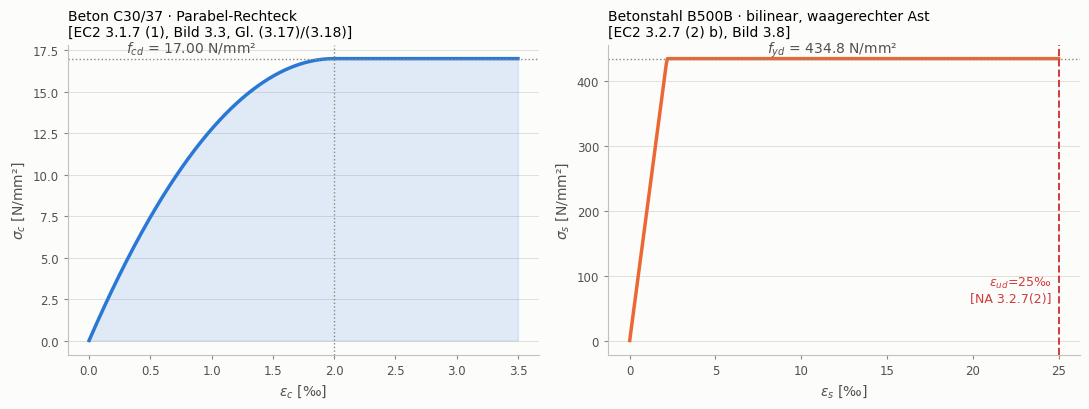

In [5]:
# --- GRAFIK: Bemessungs-Spannungs-Dehnungs-Linien ---------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
e = np.linspace(0, C.eps_cu2, 400)
a1.plot(e, [C.sigma_c(v) for v in e], color=G.C1, lw=2.5)
a1.fill_between(e, 0, [C.sigma_c(v) for v in e], color=G.C1, alpha=0.13)
a1.axvline(C.eps_c2, color=G.MUT, ls=":", lw=1); a1.axhline(C.fcd, color=G.MUT, ls=":", lw=1)
a1.text(0.3, C.fcd*1.02, f"$f_{{cd}}$ = {C.fcd:.2f} N/mm²", color=G.INK2)
a1.set_xlabel("$\\varepsilon_c$ [‰]"); a1.set_ylabel("$\\sigma_c$ [N/mm²]")
a1.set_title(f"Beton {C.klasse} · Parabel-Rechteck\n[EC2 3.1.7 (1), Bild 3.3, Gl. (3.17)/(3.18)]",
             fontsize=10, loc="left"); G._stil(a1)
es = np.linspace(0, S.eps_ud, 400)
a2.plot(es, [S.sigma_s(v) for v in es], color=G.C2, lw=2.5)
a2.axhline(S.fyd, color=G.MUT, ls=":", lw=1)
a2.text(8, S.fyd*1.02, f"$f_{{yd}}$ = {S.fyd:.1f} N/mm²", color=G.INK2)
a2.axvline(S.eps_ud, color=G.NOK, ls="--", lw=1.4)
a2.text(S.eps_ud-0.4, 60, f"$\\varepsilon_{{ud}}$={S.eps_ud:.0f}‰\n[NA 3.2.7(2)]",
        color=G.NOK, fontsize=9, ha="right")
a2.set_xlabel("$\\varepsilon_s$ [‰]"); a2.set_ylabel("$\\sigma_s$ [N/mm²]")
a2.set_title(f"Betonstahl {S.sorte} · bilinear, waagerechter Ast\n[EC2 3.2.7 (2) b), Bild 3.8]",
             fontsize=10, loc="left"); G._stil(a2)
plt.tight_layout(); plt.show()

---
# Schritt 2 · Dauerhaftigkeit und Betondeckung — `[EC2 4.4]`

$$c_{nom}=c_{min}+\Delta c_{dev} \qquad \text{`[EC2 4.4.1.1 (2)P, Gl. (4.1)]`}$$
$$c_{min}=\max\{c_{min,b};\ c_{min,dur};\ 10\ \text{mm}\} \qquad \text{`[EC2 4.4.1.2 (2)P, Gl. (4.2)]`}$$

* $c_{min,dur}$ je Expositionsklasse &nbsp; `[NA Tab. 4.4DE]`
* $\Delta c_{dev}=15$ mm, **10 mm** bei XC1 &nbsp; `[NA NDP zu 4.4.1.3 (1)P]`

### Statische Nutzhöhe

$$d_1=c_{nom,w}+\varnothing_w+\frac{\varnothing_l}{2}\qquad\qquad d=h-d_1$$

In [6]:
bd = betondeckung(expositionsklasse, phi_l, phi_w, d_g, beton=C)
c_nom_w, c_nom_l = bd["c_nom_w"], bd["c_nom_l"]
d_1 = c_nom_w + phi_w + phi_l/2.0
d   = h - d_1

print(f"Expositionsklasse {expositionsklasse}: {bd['beschreibung']}   [EC2 4.2, Tab. 4.1]")
print(f"  c_min,dur   = {bd['c_min_dur']:.0f} mm                 [NA Tab. 4.4DE]")
print(f"  c_min       = max({phi_w:.0f}; {bd['c_min_dur']:.0f}; 10) = {bd['c_min_w']:.0f} mm   [Gl. (4.2)]")
print(f"  Δc_dev      = {bd['Delta_c_dev']:.0f} mm                 [NA NDP zu 4.4.1.3 (1)P]")
print(f"  c_nom (Bügel)      = {c_nom_w:.0f} mm            [Gl. (4.1)]")
print(f"  c_nom (Längsstab)  = {c_nom_l:.0f} mm")
print(f"  w_max = {bd['w_max']:.2f} mm (Rissbreite)     [NA Tab. 7.1DE]")
print(f"\n  d_1 = {c_nom_w:.0f} + {phi_w:.0f} + {phi_l:.0f}/2 = {d_1:.1f} mm")
print(f"  d   = h - d_1 = {h:.0f} - {d_1:.1f} = {d:.1f} mm")

qs = Querschnitt(b=b_w, h=h, d1=d_1, d2=d1_schaetzung(c_nom_w, phi_w, 16.0))
print(f"\n  {qs.beschreibung()}   d = {qs.d:.1f} mm")

Expositionsklasse XC1: Trocken oder staendig nass (Karbonatisierung)   [EC2 4.2, Tab. 4.1]
  c_min,dur   = 10 mm                 [NA Tab. 4.4DE]
  c_min       = max(10; 10; 10) = 10 mm   [Gl. (4.2)]
  Δc_dev      = 10 mm                 [NA NDP zu 4.4.1.3 (1)P]
  c_nom (Bügel)      = 20 mm            [Gl. (4.1)]
  c_nom (Längsstab)  = 30 mm
  w_max = 0.40 mm (Rissbreite)     [NA Tab. 7.1DE]

  d_1 = 20 + 10 + 20/2 = 40.0 mm
  d   = h - d_1 = 700 - 40.0 = 660.0 mm

  Rechteckquerschnitt b/h = 400/700 mm   d = 660.0 mm


---
# Schritt 3 · Einwirkungen und Schnittgrößen

## 3.1 Eigengewicht — `[EC1 (DIN EN 1991-1-1), Tab. A.1]`
$$g_{EG}=\gamma\cdot A_c=25{,}0\ \text{kN/m}^3\cdot b_w\,h$$

## 3.2 Grundkombination GZT — `[EC0 6.4.3.2, Gl. (6.10)]`
$$E_d=\sum \gamma_{G,j}G_{k,j}\;+\;\gamma_{Q,1}Q_{k,1}\;+\;\sum \gamma_{Q,i}\psi_{0,i}Q_{k,i}$$
mit $\gamma_G=1{,}35$, $\gamma_Q=1{,}50$ &nbsp; `[EC0/NA, Tab. NA.A.1.2(B)]`.

## 3.3 Quasi-ständige Kombination GZG — `[EC0 6.5.3, Gl. (6.16b)]`
$$E_{d,perm}=\sum G_{k,j}+\sum \psi_{2,i}Q_{k,i}\ ,\qquad \psi_2=0{,}3$$

## 3.4 Schnittgrößen

Einfeldträger:
$$M_{Ed,max}=\frac{q_{Ed}L^2}{8}\qquad V_{Ed}(x)=q_{Ed}\left(\frac{L}{2}-x\right)$$

Die **Bemessungsquerkraft** wird bei direkter Lagerung im Abstand $d$ vom **Auflagerrand**
angesetzt `[EC2 6.2.1 (8)]`.

In [7]:
gamma_G, gamma_Q, psi_2 = 1.35, 1.50, 0.30
g_EG  = 25.0 * (b_w * h) / 1e6
G_k   = g_k + g_EG
q_Ed  = gamma_G*G_k + gamma_Q*q_k
q_qs  = G_k + psi_2*q_k

M_Ed = q_Ed * L**2 / 8.0
V_Ed_aufl = q_Ed * L / 2.0
x_rand = a_aufl/2.0
x_d    = x_rand + d/1000.0
V_Ed_d = q_Ed * (L/2.0 - x_d)

print(f"  g_EG = 25,0 · {b_w*h/1e6:.4f} m² = {g_EG:.2f} kN/m      [EC1 Tab. A.1]")
print(f"  G_k  = {g_k:.2f} + {g_EG:.2f} = {G_k:.2f} kN/m   |   q_k = {q_k:.2f} kN/m")
print(f"\n  GZT  q_Ed = 1,35·{G_k:.2f} + 1,50·{q_k:.2f} = {q_Ed:.2f} kN/m   [EC0 Gl. (6.10)]")
print(f"  GZG  q_qs = {G_k:.2f} + 0,30·{q_k:.2f} = {q_qs:.2f} kN/m        [EC0 Gl. (6.16b)]")
print(f"\n  M_Ed,max = q_Ed L²/8 = {M_Ed:.2f} kNm")
print(f"  V_Ed(Auflager) = {V_Ed_aufl:.2f} kN")
print(f"  V_Ed(Rand + d) bei x = {x_d:.3f} m  →  {V_Ed_d:.2f} kN   [EC2 6.2.1 (8)]")
print(f"  T_Ed = {T_Ed:.2f} kNm")

traeger = Durchlauftraeger(L, [Auflager(0.0, GELENKIG, a_aufl),
                               Auflager(L, GELENKIG, a_aufl)],
                           EI=C.Ecm*qs.traegheitsmoment()/1e9)
traeger.strecke(0, L, G_k, art="G").strecke(0, L, q_k, art="Q")
einh = traeger.einhuellende(gamma_G, gamma_Q, laststellungen=True)
qs_last = traeger.quasi_staendig(psi_2)
print(f"\n  din_balken: M_Ed,max = {einh['Mmax'].max():.2f} kNm | "
      f"V_Ed,max = {np.abs(einh['Vmax']).max():.2f} kN | M_qs = {qs_last.M.max():.2f} kNm")

  g_EG = 25,0 · 0.2800 m² = 7.00 kN/m      [EC1 Tab. A.1]
  G_k  = 18.00 + 7.00 = 25.00 kN/m   |   q_k = 22.00 kN/m

  GZT  q_Ed = 1,35·25.00 + 1,50·22.00 = 66.75 kN/m   [EC0 Gl. (6.10)]
  GZG  q_qs = 25.00 + 0,30·22.00 = 31.60 kN/m        [EC0 Gl. (6.16b)]

  M_Ed,max = q_Ed L²/8 = 408.84 kNm
  V_Ed(Auflager) = 233.62 kN
  V_Ed(Rand + d) bei x = 0.810 m  →  179.56 kN   [EC2 6.2.1 (8)]
  T_Ed = 45.00 kNm

  din_balken: M_Ed,max = 408.84 kNm | V_Ed,max = 233.62 kN | M_qs = 193.55 kNm


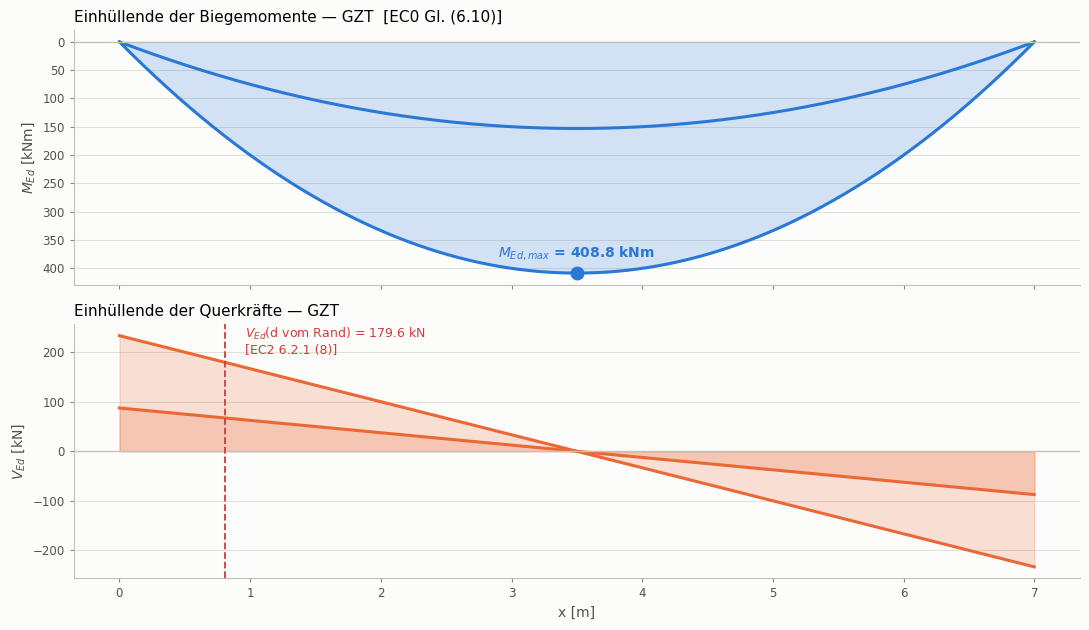

In [8]:
# --- GRAFIK: Schnittgrößen ---------------------------------------------------
x = einh["x"]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
a1.fill_between(x, 0, einh["Mmax"], color=G.C1, alpha=0.20)
a1.plot(x, einh["Mmax"], color=G.C1, lw=2.2); a1.plot(x, einh["Mmin"], color=G.C1, lw=2.2)
i = int(np.argmax(einh["Mmax"]))
a1.plot(x[i], einh["Mmax"][i], "o", color=G.C1, ms=9)
a1.annotate(f"$M_{{Ed,max}}$ = {einh['Mmax'][i]:.1f} kNm", (x[i], einh["Mmax"][i]),
            textcoords="offset points", xytext=(0, 12), ha="center", color=G.C1,
            fontweight="bold")
a1.invert_yaxis(); a1.axhline(0, color=G.AXIS, lw=1)
a1.set_ylabel("$M_{Ed}$ [kNm]")
a1.set_title("Einhüllende der Biegemomente — GZT  [EC0 Gl. (6.10)]", loc="left", fontsize=11)
G._stil(a1)
a2.fill_between(x, 0, einh["Vmax"], color=G.C2, alpha=0.20)
a2.fill_between(x, 0, einh["Vmin"], color=G.C2, alpha=0.20)
a2.plot(x, einh["Vmax"], color=G.C2, lw=2.2); a2.plot(x, einh["Vmin"], color=G.C2, lw=2.2)
a2.axhline(0, color=G.AXIS, lw=1); a2.axvline(x_d, color=G.NOK, ls="--", lw=1.3)
a2.annotate(f"$V_{{Ed}}$(d vom Rand) = {V_Ed_d:.1f} kN\n[EC2 6.2.1 (8)]", (x_d, V_Ed_d),
            textcoords="offset points", xytext=(14, 6), color=G.NOK, fontsize=9)
a2.set_ylabel("$V_{Ed}$ [kN]"); a2.set_xlabel("x [m]")
a2.set_title("Einhüllende der Querkräfte — GZT", loc="left", fontsize=11); G._stil(a2)
plt.tight_layout(); plt.show()

---
# Schritt 4 · Biegebemessung (GZT) — `[EC2 6.1]`

## 4.1 Bemessungsannahmen — `[EC2 6.1 (2)P]`

1. Ebenbleiben der Querschnitte (**Bernoulli**).
2. Vollständiger Verbund: $\varepsilon_s=\varepsilon_c$ in gleicher Höhe.
3. Die **Zugfestigkeit des Betons** wird nicht angesetzt.
4. Beton: Parabel-Rechteck `[3.1.7 (1)]`; Betonstahl: bilinear `[3.2.7 (2)]`.
5. Grenzdehnungen (**Bemessungspunkte**, `Bild 6.1`):
   * $\varepsilon_{cu2}=3{,}5\ ‰$ am gedrückten Rand
   * $\varepsilon_{ud}=25\ ‰$ in der Zugbewehrung &nbsp; `[NA NDP zu 3.2.7 (2)]`

**Punkt A** ($x\le x_A$): der Stahl ist maßgebend, $\varepsilon_{s}=25‰$.
**Punkt B** ($x> x_A$): der Beton ist maßgebend, $\varepsilon_c=3{,}5‰$.

$$x_A=d\,\frac{\varepsilon_{cu2}}{\varepsilon_{cu2}+\varepsilon_{ud}}=d\,\frac{3{,}5}{28{,}5}=0{,}1228\,d$$

## 4.2 Bezogenes Moment und Duktilitätsgrenze

$$M_{Eds}=M_{Ed}-N_{Ed}\,z_{s1}\qquad
\boxed{\ \mu_{Eds}=\frac{M_{Eds}}{b\,d^{2}\,f_{cd}}\ }$$

Duktilitätsgrenze `[NA NDP zu 5.5 (4), Gl. (5.10a)]`:

$$\delta\ \ge\ k_1+k_2\,\frac{x_u}{d}\ ,\qquad k_1=0{,}64,\ k_2=0{,}80\quad(\le \text{C50/60})$$

Ohne Umlagerung ($\delta=1{,}0$):

$$\frac{x_u}{d}\le\frac{1{,}0-0{,}64}{0{,}80}=\mathbf{0{,}45}
\quad\Longrightarrow\quad
\mu_{lim}=\alpha_R\,\xi_{lim}\,(1-k_a\,\xi_{lim})=\mathbf{0{,}296}$$

In [9]:
N_Ed = 0.0
M_Eds = M_Ed - N_Ed * qs.z_s1/1000.0
mu_Eds = M_Eds*1e6 / (b_w * d**2 * f_cd)
grenz = xi_grenz(C, delta=1.0)
xi_lim = grenz["xi_lim"]
aR, ka = C.alpha_R(C.eps_cu2), C.k_a(C.eps_cu2)
mu_lim = aR*xi_lim*(1 - ka*xi_lim)
x_A = d * C.eps_cu2/(C.eps_cu2 + S.eps_ud)

print(f"  x_A = d·ε_cu2/(ε_cu2+ε_ud) = {x_A:.1f} mm  (ξ_A = {x_A/d:.4f})")
print(f"  M_Eds  = {M_Eds:.2f} kNm")
print(f"  μ_Eds  = {M_Eds:.2f}·10⁶/({b_w:.0f}·{d:.1f}²·{f_cd:.2f}) = {mu_Eds:.4f}")
print(f"\n  ξ_lim  = (δ-k1)/k2 = (1,00-{grenz['k1']})/{grenz['k2']} = {xi_lim:.3f}   [NA NDP zu 5.5 (4)]")
print(f"  μ_lim  = α_R·ξ_lim·(1-k_a·ξ_lim) = {mu_lim:.4f}")
print(f"\n  μ_Eds = {mu_Eds:.4f}  {'≤' if mu_Eds<=mu_lim else '>'}  μ_lim = {mu_lim:.4f}"
      f"  →  {'EINFACHE BEWEHRUNG' if mu_Eds<=mu_lim else 'DRUCKBEWEHRUNG ERFORDERLICH'}")

  x_A = d·ε_cu2/(ε_cu2+ε_ud) = 81.1 mm  (ξ_A = 0.1228)
  M_Eds  = 408.84 kNm
  μ_Eds  = 408.84·10⁶/(400·660.0²·17.00) = 0.1380

  ξ_lim  = (δ-k1)/k2 = (1,00-0.64)/0.8 = 0.450   [NA NDP zu 5.5 (4)]
  μ_lim  = α_R·ξ_lim·(1-k_a·ξ_lim) = 0.2961

  μ_Eds = 0.1380  ≤  μ_lim = 0.2961  →  EINFACHE BEWEHRUNG


## 4.3 Auflösung: $\xi$, $\zeta$, $\omega$ und $A_{s1}$

Mit $F_{cd}=\alpha_R\,b\,x\,f_{cd}$ im Abstand $k_a\,x$ vom Rand liefert das Momenten­gleichgewicht
um $A_{s1}$:

$$\mu_{Eds}=\alpha_R\,\xi\,(1-k_a\,\xi)\ ,\qquad \xi=\frac{x}{d}$$

— eine **quadratische Gleichung in $\xi$** (gültig solange $\varepsilon_c=\varepsilon_{cu2}$, Punkt B):

$$\xi=\frac{\alpha_R-\sqrt{\alpha_R^{2}-4\,\alpha_R k_a\,\mu_{Eds}}}{2\,\alpha_R k_a}
\qquad \zeta=1-k_a\,\xi \qquad \omega=\alpha_R\,\xi$$

$$\varepsilon_{s1}=\varepsilon_{cu2}\,\frac{1-\xi}{\xi}
\qquad\qquad
\boxed{\ A_{s1}=\frac{1}{\sigma_{s1}}\left(\omega\,b\,d\,f_{cd}+N_{Ed}\right)\ }$$

In [10]:
A_, B_, Cc_ = aR*ka, -aR, mu_Eds
xi   = (-B_ - math.sqrt(B_**2 - 4*A_*Cc_)) / (2*A_)
zeta = 1.0 - ka*xi
omega = aR*xi
x_na, z = xi*d, zeta*d
eps_s1 = C.eps_cu2*(1-xi)/xi
sigma_s1 = S.sigma_s(eps_s1)
F_cd = omega * b_w * d * f_cd / 1e3
As1_erf = (omega*b_w*d*f_cd + N_Ed*1e3)/sigma_s1

print(f"  ξ = x/d = {xi:.4f}   →  x = {x_na:.1f} mm")
print(f"  ζ = z/d = {zeta:.4f} →  z = {z:.1f} mm")
print(f"  ω       = α_R·ξ = {omega:.4f}")
print(f"  ε_s1    = ε_cu2(1-ξ)/ξ = {eps_s1:.2f} ‰  ≥ ε_yd = {S.eps_yd:.2f} ‰"
      f"  →  σ_s1 = {sigma_s1:.1f} N/mm²")
print(f"  F_cd    = {F_cd:.1f} kN")
print(f"  A_s1,erf (Biegung) = {As1_erf:.0f} mm²")
print(f"  Kontrolle über M/z: {M_Eds*1e6/(z*sigma_s1):.0f} mm²")

r_bieg = bemessung_biegung(qs, C, S, M_Ed, N_Ed)
print(f"\n  din_balken: μ={r_bieg.mu_Eds:.4f}  ξ={r_bieg.xi:.4f}  ζ={r_bieg.zeta:.4f}"
      f"  ω={r_bieg.omega:.4f}  A_s1={r_bieg.As1:.0f} mm² (Punkt {r_bieg.punkt})")

n_staebe = math.ceil(As1_erf/stabflaeche(phi_l))
As1_vorh = stabflaeche_n(n_staebe, phi_l)
platz = platznachweis(b_w, n_staebe, phi_l, c_nom_w, phi_w, d_g)
print(f"\n  GEWÄHLT: {n_staebe} ⌀{phi_l:.0f} = {As1_vorh:.0f} mm²  "
      f"(A_s,vorh/A_s,erf = {As1_vorh/As1_erf:.3f})")
print(f"  Platznachweis [EC2 8.2 (2)]: b_erf = {platz['b_erf']:.0f} mm "
      f"{'≤' if platz['ok'] else '>'} b = {b_w:.0f} mm")
mr = momententragfaehigkeit(qs, C, S, As1_vorh, 0.0, N_Ed)
print(f"  NACHWEIS: M_Rd = {mr['M_Rd']:.2f} kNm ≥ M_Ed = {M_Ed:.2f} kNm "
      f"(η = {M_Ed/mr['M_Rd']:.3f})")

  ξ = x/d = 0.1847   →  x = 121.9 mm
  ζ = z/d = 0.9232 →  z = 609.3 mm
  ω       = α_R·ξ = 0.1495
  ε_s1    = ε_cu2(1-ξ)/ξ = 15.45 ‰  ≥ ε_yd = 2.17 ‰  →  σ_s1 = 434.8 N/mm²
  F_cd    = 671.0 kN
  A_s1,erf (Biegung) = 1543 mm²
  Kontrolle über M/z: 1543 mm²

  din_balken: μ=0.1380  ξ=0.1847  ζ=0.9232  ω=0.1495  A_s1=1543 mm² (Punkt B)

  GEWÄHLT: 5 ⌀20 = 1571 mm²  (A_s,vorh/A_s,erf = 1.018)
  Platznachweis [EC2 8.2 (2)]: b_erf = 244 mm ≤ b = 400 mm
  NACHWEIS: M_Rd = 415.50 kNm ≥ M_Ed = 408.84 kNm (η = 0.984)


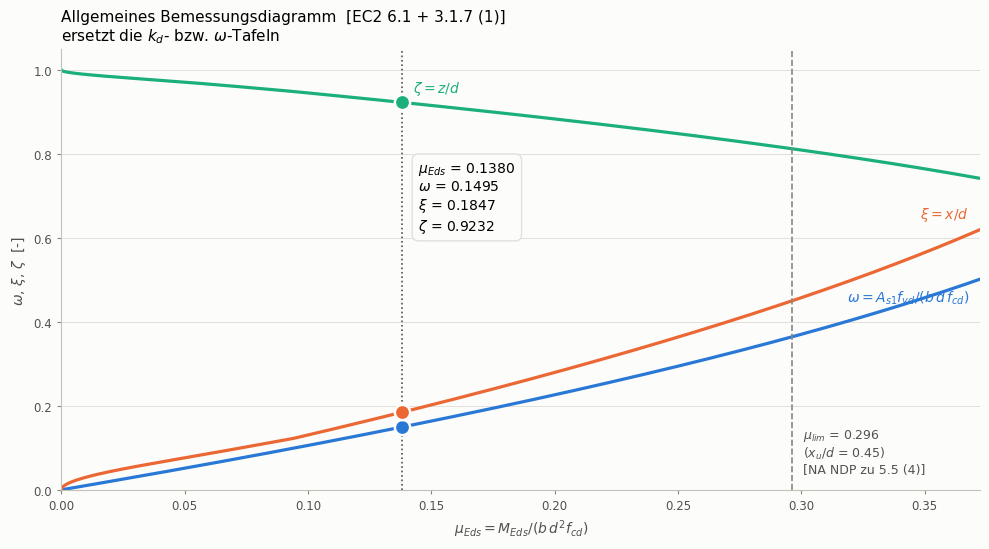

In [11]:
# --- GRAFIK: Allgemeines Bemessungsdiagramm ---------------------------------
dg = bemessungsdiagramm(C, S, n=400, xi_max=0.62)
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.plot(dg["mu"], dg["omega"], color=G.C1, lw=2.3)
ax.plot(dg["mu"], dg["xi"],    color=G.C2, lw=2.3)
ax.plot(dg["mu"], dg["zeta"],  color=G.C3, lw=2.3)
ax.annotate("$\\omega = A_{s1}f_{yd}/(b\\,d\\,f_{cd})$", (dg["mu"][-1], dg["omega"][-1]),
            textcoords="offset points", xytext=(-8, -16), ha="right", color=G.C1, fontweight="bold")
ax.annotate("$\\xi = x/d$", (dg["mu"][-1], dg["xi"][-1]), textcoords="offset points",
            xytext=(-8, 8), ha="right", color=G.C2, fontweight="bold")
ax.annotate("$\\zeta = z/d$", (dg["mu"][120], dg["zeta"][120]),
            textcoords="offset points", xytext=(6, 8), color=G.C3, fontweight="bold")
ax.axvline(mu_lim, color=G.MUT, ls="--", lw=1.2)
ax.annotate(f"$\\mu_{{lim}}$ = {mu_lim:.3f}\n($x_u/d$ = {xi_lim:.2f})\n[NA NDP zu 5.5 (4)]",
            (mu_lim, 0.04), textcoords="offset points", xytext=(8, 0), color=G.INK2, fontsize=9)
ax.axvline(mu_Eds, color=G.INK2, ls=":", lw=1.2)
for val, col in ((omega, G.C1), (xi, G.C2), (zeta, G.C3)):
    ax.plot(mu_Eds, val, "o", color=col, ms=11, mec="#fcfcfb", mew=1.8, zorder=5)
ax.annotate(f"$\\mu_{{Eds}}$ = {mu_Eds:.4f}\n$\\omega$ = {omega:.4f}\n"
            f"$\\xi$ = {xi:.4f}\n$\\zeta$ = {zeta:.4f}",
            (mu_Eds, 0.62), textcoords="offset points", xytext=(12, 0), fontsize=10,
            bbox=dict(fc="#fcfcfb", ec=G.GRID, boxstyle="round,pad=0.45"))
ax.set_xlabel("$\\mu_{Eds} = M_{Eds}/(b\\,d^2 f_{cd})$")
ax.set_ylabel("$\\omega$, $\\xi$, $\\zeta$  [-]")
ax.set_xlim(0, dg["mu"][-1]); ax.set_ylim(0, 1.05)
ax.set_title("Allgemeines Bemessungsdiagramm  [EC2 6.1 + 3.1.7 (1)]\n"
             "ersetzt die $k_d$- bzw. $\\omega$-Tafeln", loc="left", fontsize=11)
G._stil(ax); plt.tight_layout(); plt.show()

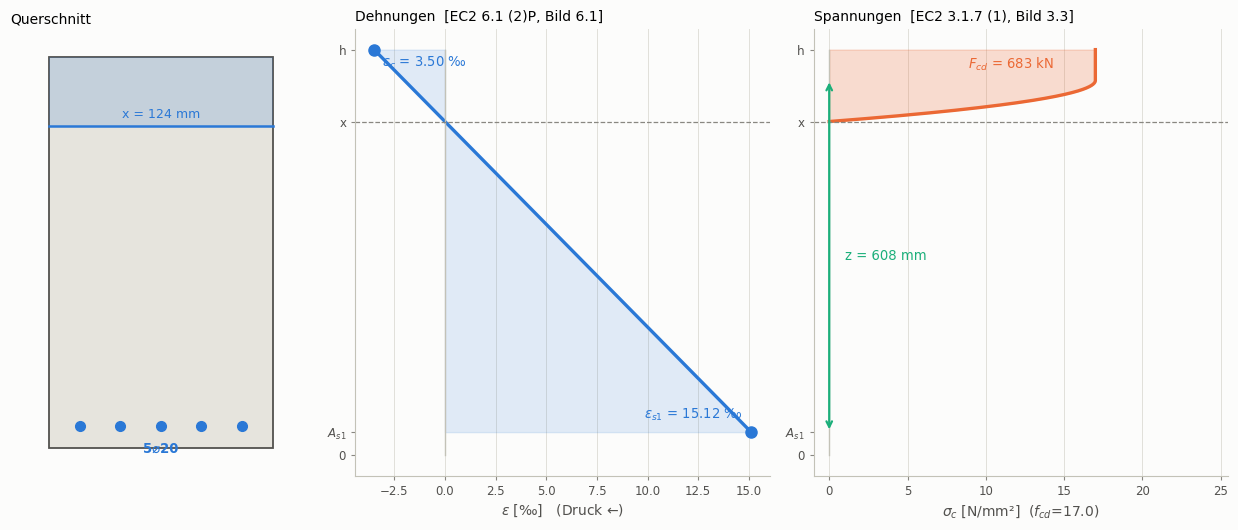

In [12]:
# --- GRAFIK: Dehnungen und Spannungen im Bruchzustand -----------------------
fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(12.5, 5.4),
                                 gridspec_kw={"width_ratios": [0.8, 1.1, 1.1]})
xx, ec_, es_ = mr["x"], mr["eps_c"], mr["eps_s1"]
a0.add_patch(plt.Rectangle((0, 0), b_w, h, fc="#e6e4dd", ec=G.INK2, lw=1.3))
a0.add_patch(plt.Rectangle((0, h-xx), b_w, xx, fc=G.C1, alpha=0.18))
a0.plot([0, b_w], [h-xx, h-xx], color=G.C1, lw=1.8)
a0.text(b_w/2, h-xx+14, f"x = {xx:.0f} mm", ha="center", color=G.C1, fontsize=9)
a0.plot(np.linspace(55, b_w-55, n_staebe), [h-d]*n_staebe, "o", color=G.C1, ms=7)
a0.text(b_w/2, h-d-48, f"{n_staebe}⌀{phi_l:.0f}", ha="center", color=G.C1,
        fontsize=9.5, fontweight="bold")
a0.set_xlim(-70, b_w+70); a0.set_ylim(-45, h+45); a0.set_aspect("equal"); a0.axis("off")
a0.set_title("Querschnitt", loc="left", fontsize=10)
a1.plot([-ec_, es_], [h, h-d], color=G.C1, lw=2.4)
a1.fill_betweenx([h-xx, h], [0, -ec_], [0, 0], color=G.C1, alpha=0.13)
a1.fill_betweenx([h-d, h-xx], [es_, 0], [0, 0], color=G.C1, alpha=0.13)
a1.plot([0, 0], [0, h], color=G.AXIS, lw=1); a1.axhline(h-xx, color=G.MUT, ls="--", lw=0.9)
a1.plot(-ec_, h, "o", color=G.C1, ms=8); a1.plot(es_, h-d, "o", color=G.C1, ms=8)
a1.annotate(f"$\\varepsilon_c$ = {ec_:.2f} ‰", (-ec_, h), textcoords="offset points",
            xytext=(6, -12), color=G.C1, fontsize=9.5)
a1.annotate(f"$\\varepsilon_{{s1}}$ = {es_:.2f} ‰", (es_, h-d), textcoords="offset points",
            xytext=(-6, 10), ha="right", color=G.C1, fontsize=9.5)
a1.set_yticks([0, h-d, h-xx, h]); a1.set_yticklabels(["0", "$A_{s1}$", "x", "h"])
a1.set_xlabel("$\\varepsilon$ [‰]   (Druck ←)")
a1.set_title("Dehnungen  [EC2 6.1 (2)P, Bild 6.1]", loc="left", fontsize=10)
G._stil(a1, grid="x")
ys = np.linspace(h-xx, h, 250)
sg = np.array([C.sigma_c(ec_*(y-(h-xx))/xx) for y in ys])
a2.fill_betweenx(ys, 0, sg, color=G.C2, alpha=0.22); a2.plot(sg, ys, color=G.C2, lw=2.4)
a2.plot([0, 0], [0, h], color=G.AXIS, lw=1); a2.axhline(h-xx, color=G.MUT, ls="--", lw=0.9)
y_res = h - (d - mr["z"])
a2.annotate("", (0, y_res), (0, h-d), arrowprops=dict(arrowstyle="<->", color=G.C3, lw=1.6))
a2.text(1.0, (y_res+h-d)/2, f"z = {mr['z']:.0f} mm", color=G.C3, va="center", fontsize=9.5)
a2.annotate(f"$F_{{cd}}$ = {As1_vorh*mr['sigma_s1']/1000:.0f} kN", (f_cd*0.5, y_res),
            textcoords="offset points", xytext=(4, 8), color=G.C2, fontsize=9.5)
a2.set_yticks([0, h-d, h-xx, h]); a2.set_yticklabels(["0", "$A_{s1}$", "x", "h"])
a2.set_xlabel(f"$\\sigma_c$ [N/mm²]  ($f_{{cd}}$={f_cd:.1f})"); a2.set_xlim(-1, f_cd*1.5)
a2.set_title("Spannungen  [EC2 3.1.7 (1), Bild 3.3]", loc="left", fontsize=10)
G._stil(a2, grid="x")
plt.tight_layout(); plt.show()

## 4.4 Fall mit Druckbewehrung ($\mu_{Eds}>\mu_{lim}$) — `[EC2 6.1]`

Übersteigt das Moment $\mu_{lim}$, wird $x=x_{lim}=0{,}45\,d$ festgehalten und der Überschuss
von einem Stahl-Stahl-Kräftepaar aufgenommen:

$$\Delta M=M_{Eds}-\mu_{lim}\,b\,d^{2}f_{cd}
\qquad
A_{s2}=\frac{\Delta M}{(d-d_2)\,\sigma_{s2}}\ ,\qquad
\varepsilon_{s2}=\varepsilon_{cu2}\frac{x_{lim}-d_2}{x_{lim}}$$
$$A_{s1}=\frac{1}{f_{yd}}\left(\frac{M_{lim}}{z_{lim}}+A_{s2}\sigma_{s2}+N_{Ed}\right)$$

In [13]:
d_2   = qs.d2
M_lim = mu_lim * b_w * d**2 * f_cd / 1e6
M_gross = 1.35 * M_lim          # deutlich über M_lim

mu_2   = M_gross*1e6/(b_w*d**2*f_cd)
x_lim  = xi_lim*d
z_lim  = (1.0 - ka*xi_lim)*d
dM     = M_gross - M_lim
eps_s2 = C.eps_cu2*(x_lim - d_2)/x_lim
sig_s2 = S.sigma_s(eps_s2)
As2_m  = dM*1e6/((d - d_2)*sig_s2)
As1_m  = (M_lim*1e6/z_lim + As2_m*sig_s2)/S.fyd

print(f"  M_lim = μ_lim·b·d²·f_cd = {M_lim:.2f} kNm  (Grenze der einfachen Bewehrung)")
print(f"  M_Ed  = {M_gross:.1f} kNm → μ_Eds = {mu_2:.4f} > μ_lim = {mu_lim:.4f}")
print(f"  x_lim = {xi_lim:.2f}·d = {x_lim:.1f} mm    z_lim = {z_lim:.1f} mm")
print(f"  ΔM    = {dM:.2f} kNm")
print(f"  ε_s2  = {eps_s2:.2f} ‰ → σ_s2 = {sig_s2:.1f} N/mm²")
print(f"  A_s2  = {As2_m:.0f} mm²      A_s1 = {As1_m:.0f} mm²")
r2 = bemessung_biegung(qs, C, S, M_gross, 0.0)
print(f"\n  din_balken: A_s1 = {r2.As1:.0f} mm²   A_s2 = {r2.As2:.0f} mm²   ξ = {r2.xi:.3f}")
mr2 = momententragfaehigkeit(qs, C, S, r2.As1, r2.As2)
print(f"  Kontrolle: M_Rd = {mr2['M_Rd']:.2f} kNm  (M_Ed = {M_gross:.1f} kNm)")

  M_lim = μ_lim·b·d²·f_cd = 877.06 kNm  (Grenze der einfachen Bewehrung)
  M_Ed  = 1184.0 kNm → μ_Eds = 0.3997 > μ_lim = 0.2961
  x_lim = 0.45·d = 297.0 mm    z_lim = 536.5 mm
  ΔM    = 306.97 kNm
  ε_s2  = 3.05 ‰ → σ_s2 = 434.8 N/mm²
  A_s2  = 1135 mm²      A_s1 = 4895 mm²

  din_balken: A_s1 = 4895 mm²   A_s2 = 1135 mm²   ξ = 0.450
  Kontrolle: M_Rd = 1184.03 kNm  (M_Ed = 1184.0 kNm)


---
# Schritt 5 · Mindest- und Höchstbewehrung — `[EC2 9.2.1.1]`

**Mindestbewehrung für Biegung** `Gl. (9.1N)`:
$$A_{s,min}=\max\left\{0{,}26\,\frac{f_{ctm}}{f_{yk}}\,b_t\,d\ ;\ 0{,}0013\,b_t\,d\right\}$$

**Robustheitsbewehrung** (*duktiles Bauteilverhalten*) `[NA NDP zu 9.2.1.1 (1)]` — die Bewehrung
muss das mit $f_{ctm}$ berechnete Rissmoment aufnehmen können:
$$M_{cr}=f_{ctm}\,W\qquad A_{s,rob}=\frac{M_{cr}}{f_{yk}\,z}$$

**Mindestbewehrung für die Rissbreitenbegrenzung** `[EC2 7.3.2 (2), Gl. (7.1)]`:
$$A_{s,min}\,\sigma_s=k_c\,k\,f_{ct,eff}\,A_{ct}$$

**Höchstbewehrung** `[NA NDP zu 9.2.1.1 (3)]`: $A_{s,max}=0{,}04\,A_c$

In [14]:
amin = mindestbewehrung_biegung(qs, C, S)
arob = robustheitsbewehrung(qs, C, S)
ariss = mindestbewehrung_riss(qs, C, S)
amax = hoechstbewehrung(qs)

print(f"  A_s,min (9.1N) = max({amin['term_fctm']:.0f} ; {amin['term_0013']:.0f})"
      f" = {amin['As_min']:.0f} mm²   (maßgebend: {amin['massgebend']})")
print(f"  A_s,rob        = M_cr/(f_yk·z), M_cr = {arob['Mcr']:.2f} kNm → {arob['As_rob']:.0f} mm²")
print(f"  A_s,min (Riss) = {ariss['As_min']:.0f} mm²  (k_c={ariss['kc']:.2f}, k={ariss['k']:.2f})")
print(f"  A_s,max        = 0,04·A_c = {amax['As_max']:.0f} mm²")
As_min_ges = max(amin["As_min"], arob["As_rob"])
print(f"\n  A_s,vorh = {As1_vorh:.0f} mm² ≥ {As_min_ges:.0f} mm² ✓  und ≤ {amax['As_max']:.0f} mm² ✓")

  A_s,min (9.1N) = max(398 ; 343) = 398 mm²   (maßgebend: 0,26 fctm/fyk bt d)
  A_s,rob        = M_cr/(f_yk·z), M_cr = 94.62 kNm → 319 mm²
  A_s,min (Riss) = 234 mm²  (k_c=0.40, k=0.72)
  A_s,max        = 0,04·A_c = 11200 mm²

  A_s,vorh = 1571 mm² ≥ 398 mm² ✓  und ≤ 11200 mm² ✓


---
# Schritt 6 · Querkraftbemessung — `[EC2 6.2]`

## 6.1 Innerer Hebelarm — `[NA NDP zu 6.2.3 (1)]`
$$z=\min\{0{,}9\,d\ ;\ d-2\,c_{v,l}\ ;\ d-c_{v,l}-30\ \text{mm}\}$$

## 6.2 Tragfähigkeit ohne Querkraftbewehrung — `[EC2 6.2.2 (1), Gl. (6.2a)/(6.2b)]`
$$V_{Rd,c}=\Big[C_{Rd,c}\,k\,(100\,\rho_l f_{ck})^{1/3}+k_1\sigma_{cp}\Big]b_w d
\ \ \ge\ (v_{min}+k_1\sigma_{cp})\,b_w d$$

**Deutsche Parameter** `[NA NDP zu 6.2.2 (1)]`:
$$C_{Rd,c}=\frac{0{,}15}{\gamma_C}=0{,}10\qquad k_1=0{,}12\qquad
k=1+\sqrt{200/d}\le 2{,}0\qquad \rho_l=\frac{A_{sl}}{b_w d}\le 0{,}02$$
$$v_{min}=\frac{\kappa_1}{\gamma_C}\,k^{3/2}\,f_{ck}^{1/2}\ ,\quad
\kappa_1=0{,}0525\ (d\le 600)\ ;\ 0{,}0375\ (d\ge 800)\qquad\text{`Gl. (6.3aDE)`}$$

> 🇩🇪 Der Eurocode empfiehlt $C_{Rd,c}=0{,}18/\gamma_C=0{,}12$; der NA **senkt ihn auf 0,10**.

## 6.3 Druckstrebenneigung — `[NA NDP zu 6.2.3 (2), Gl. (6.7aDE)/(6.7bDE)]`

Einer der **auffälligsten Unterschiede** zum Eurocode ohne NA (dort nur $1{,}0\le\cot\theta\le2{,}5$ ohne Formel):

$$\cot\theta=\frac{1{,}2+1{,}4\,\dfrac{\sigma_{cd}}{f_{cd}}}{1-\dfrac{V_{Rd,cc}}{V_{Ed}}}
\qquad\qquad 1{,}0\le\cot\theta\le 3{,}0$$

$$V_{Rd,cc}=c\cdot 0{,}48\cdot f_{ck}^{1/3}\left(1-1{,}2\,\frac{\sigma_{cd}}{f_{cd}}\right)b_w\,z\ ,\qquad c=0{,}5$$

## 6.4 Druckstrebe und Bügel — `[EC2 6.2.3 (3), Gl. (6.9)/(6.8)]`

$$V_{Rd,max}=\frac{\alpha_{cw}\,b_w\,z\,\nu_1\,f_{cd}}{\cot\theta+\tan\theta}\ ,\quad
\nu_1=0{,}75\,\nu_2 \quad\text{`[NA NDP zu 6.2.3 (3)]`}
\qquad\qquad
\frac{A_{sw}}{s}=\frac{V_{Ed}}{z\,f_{ywd}\,\cot\theta}$$

## 6.5 Mindestbewehrung und Abstände — `[NA NDP zu 9.2.2 (5), Tab. NA.9.1]`

$$\rho_{w,min}=0{,}16\,\frac{f_{ctm}}{f_{yk}}\qquad
\left.\frac{A_{sw}}{s}\right|_{min}=\rho_{w,min}\,b_w$$

In [15]:
hb = innerer_hebelarm(d, c_nom_l)
z_v = hb["z"]
print(f"  z = min(0,9·{d:.1f} ; {d:.1f}-2·{c_nom_l:.0f} ; {d:.1f}-{c_nom_l:.0f}-30)")
print(f"    = min({hb['z_09d']:.1f} ; {hb['z_2c']:.1f} ; {hb['z_c30']:.1f}) = {z_v:.1f} mm")

vc = V_Rd_c(C, b_w, d, As1_vorh, N_Ed, qs.Ac)
print(f"\n  k = 1+√(200/{d:.1f}) = {vc['k']:.3f}   ρ_l = {vc['rho_l']:.5f}")
print(f"  v_a = {vc['v_a']:.3f} N/mm²  [Gl. (6.2a)]   v_min = {vc['v_min']:.3f} N/mm²  [Gl. (6.3aDE)]")
print(f"  →  V_Rd,c = {vc['V_Rdc']:.1f} kN   (maßgebend {vc['massgebend']})")
print(f"  V_Ed(d) = {V_Ed_d:.1f} kN {'≤' if V_Ed_d<=vc['V_Rdc'] else '>'} V_Rd,c")

ct = cot_theta_NA(C, b_w, z_v, V_Ed_d, N_Ed, qs.Ac)
cot_t = ct["cot_theta"]
print(f"\n  V_Rd,cc = {ct['V_Rdcc']:.1f} kN   [Gl. (6.7bDE)]")
print(f"  cot θ = 1,2/(1 - {ct['V_Rdcc']:.1f}/{V_Ed_d:.1f}) = {ct['cot_roh']:.3f}"
      f" → begrenzt auf {cot_t:.3f}   [Gl. (6.7aDE)]   θ = {ct['theta_grad']:.1f}°")
vm = V_Rd_max(C, b_w, z_v, cot_t)
print(f"  V_Rd,max = {vm['V_Rdmax']:.1f} kN  (ν_1 = {vm['nu1']:.3f})   [Gl. (6.9)]"
      f"  →  η = {V_Ed_d/vm['V_Rdmax']:.3f}")

asw_V = asw_erforderlich(V_Ed_d, z_v, S.fyd, cot_t)*1000.0
am = asw_mindest(C, S, b_w); asw_min = am["asw_min"]*1000.0
sm = groesster_buegelabstand(V_Ed_d, vm["V_Rdmax"], h, C.fck)
print(f"\n  a_sw,V   = V_Ed/(z f_ywd cot θ) = {asw_V/100:.2f} cm²/m (alle Schenkel)  [Gl. (6.8)]")
print(f"  a_sw,min = 0,16·f_ctm/f_yk·b_w  = {asw_min/100:.2f} cm²/m   [NA NDP zu 9.2.2 (5)]")
print(f"  s_max = {sm['s_max']:.0f} mm  (Zeile {sm['tabellenzeile']} der Tab. NA.9.1)")
a_l = versatzmass(z_v, cot_t)["a_l"]
print(f"  Versatzmaß a_l = z cot θ/2 = {a_l:.0f} mm   [EC2 9.2.1.3 (2), Gl. (9.2)]")

  z = min(0,9·660.0 ; 660.0-2·30 ; 660.0-30-30)
    = min(594.0 ; 600.0 ; 600.0) = 594.0 mm

  k = 1+√(200/660.0) = 1.550   ρ_l = 0.00595
  v_a = 0.405 N/mm²  [Gl. (6.2a)]   v_min = 0.338 N/mm²  [Gl. (6.3aDE)]
  →  V_Rd,c = 107.0 kN   (maßgebend Gl.(6.2a))
  V_Ed(d) = 179.6 kN > V_Rd,c

  V_Rd,cc = 177.2 kN   [Gl. (6.7bDE)]
  cot θ = 1,2/(1 - 177.2/179.6) = 90.889 → begrenzt auf 3.000   [Gl. (6.7aDE)]   θ = 18.4°
  V_Rd,max = 908.8 kN  (ν_1 = 0.750)   [Gl. (6.9)]  →  η = 0.198

  a_sw,V   = V_Ed/(z f_ywd cot θ) = 2.32 cm²/m (alle Schenkel)  [Gl. (6.8)]
  a_sw,min = 0,16·f_ctm/f_yk·b_w  = 3.71 cm²/m   [NA NDP zu 9.2.2 (5)]
  s_max = 300 mm  (Zeile 1 der Tab. NA.9.1)
  Versatzmaß a_l = z cot θ/2 = 891 mm   [EC2 9.2.1.3 (2), Gl. (9.2)]


---
# Schritt 7 · Torsionsbemessung — `[EC2 6.3 + NA NDP zu 6.3.2]`

## 7.1 Gleichgewichts- oder Verträglichkeitstorsion? — `[EC2 6.3.1 (2)]`

* **Gleichgewichtstorsion**: das Torsionsmoment ist für das Gleichgewicht **erforderlich**
  (z. B. auskragende Konsole am Randbalken) → **Nachweis zwingend**.
* **Verträglichkeitstorsion**: entsteht nur aus der Verformungsverträglichkeit
  (z. B. Einspannung einer Platte in den Randbalken) → im GZT darf auf den Nachweis
  **verzichtet** werden; es genügt die Mindestbewehrung nach 9.2.2 und 9.2.3.

## 7.2 Ersatzhohlquerschnitt — `[EC2 6.3.1 (3)]`

Der Vollquerschnitt wird durch einen **dünnwandigen geschlossenen Querschnitt** ersetzt:

$$t_{ef,i}=\frac{A}{u}\quad\Big(\ge 2\,d_1\ ,\ \le \text{Wanddicke}\Big)
\qquad A_k=(b-t_{ef})(h-t_{ef})
\qquad u_k=2\big[(b-t_{ef})+(h-t_{ef})\big]$$

**Schubfluss** `Gl. (6.26)`:
$$\tau_{t,i}\,t_{ef,i}=\frac{T_{Ed}}{2\,A_k}$$

## 7.3 Rissmoment und Verzicht auf Bewehrung

$$T_{Rd,c}=f_{ctd}\,t_{ef,i}\,2\,A_k \qquad\text{`[EC2 6.3.2 (5), Gl. (6.31)]`}$$

Auf rechnerische Torsionsbewehrung darf bei Vollquerschnitten verzichtet werden, wenn
`[NA NDP zu 6.3.2 (5)]`:

$$T_{Ed}\le \frac{V_{Ed}\,b_w}{4{,}5}\quad\text{`(6.31aDE)`}
\qquad\text{und}\qquad
V_{Ed}\left[1+\frac{4{,}5\,T_{Ed}}{V_{Ed}\,b_w}\right]\le V_{Rd,c}\quad\text{`(6.31bDE)`}$$

## 7.4 Druckstrebe und Interaktion mit der Querkraft

$$T_{Rd,max}=2\,\nu\,\alpha_{cw}\,f_{cd}\,A_k\,t_{ef,i}\sin\theta\cos\theta
\qquad\text{`[EC2 6.3.2 (4), Gl. (6.30)]`}$$

mit `[NA NDP zu 6.3.2 (4)]`:
$$\nu=0{,}525\,\nu_2\ \text{(Vollquerschnitt)}\qquad
\nu=0{,}75\,\nu_2\ \text{(Kastenquerschnitt)}$$

$$\boxed{\ \frac{T_{Ed}}{T_{Rd,max}}+\frac{V_{Ed}}{V_{Rd,max}}\ \le\ 1{,}0\ }
\qquad\text{`[Gl. (6.29)]`}$$

## 7.5 Torsionsbewehrung

**Bügel** (je **Außenschenkel** des geschlossenen Bügels):
$$\frac{A_{sw}}{s}=\frac{T_{Ed}}{2\,A_k\,f_{ywd}\,\cot\theta}$$

**Längsbewehrung**, gleichmäßig über $u_k$ verteilt `[Gl. (6.28)]`:
$$\sum A_{sl}=\frac{T_{Ed}\,\cot\theta\,u_k}{2\,A_k\,f_{yd}}$$

**Konstruktive Durchbildung** `[EC2 9.2.3]`: geschlossene Bügel mit Übergreifung oder Haken;
$s\le u_k/8$ und $\le$ kleinste Querschnittsabmessung; mindestens ein Längsstab je Ecke.

In [16]:
ehq = ersatzhohlquerschnitt(qs)
print("ERSATZHOHLQUERSCHNITT  [EC2 6.3.1 (3)]")
print(f"  A = b·h = {ehq['A']:.0f} mm²      u = 2(b+h) = {ehq['u']:.0f} mm")
print(f"  t_ef = A/u = {ehq['t_ef_roh']:.1f} mm  →  gewählt {ehq['t_ef']:.1f} mm"
      f"  (≥ 2d₁ = {ehq['t_min']:.0f} mm, ≤ {ehq['t_max']:.0f} mm)")
print(f"  A_k = ({ehq['b_k']:.1f})·({ehq['h_k']:.1f}) = {ehq['A_k']:.0f} mm²")
print(f"  u_k = {ehq['u_k']:.0f} mm")

trc = T_Rd_c(C, ehq)
print(f"\n  T_Rd,c = f_ctd·t_ef·2·A_k = {C.fctd:.3f}·{ehq['t_ef']:.1f}·2·{ehq['A_k']:.0f}"
      f" = {trc['T_Rdc']:.2f} kNm   [Gl. (6.31)]")
print(f"  T_Ed = {T_Ed:.2f} kNm {'>' if T_Ed>trc['T_Rdc'] else '≤'} T_Rd,c"
      f"  →  {'Querschnitt reißt unter Torsion' if T_Ed>trc['T_Rdc'] else 'ungerissen'}")

entb = bewehrung_entbehrlich(T_Ed, V_Ed_d, b_w, vc["V_Rdc"])
print(f"\nVERZICHT AUF TORSIONSBEWEHRUNG  [NA NDP zu 6.3.2 (5)]")
print(f"  (6.31aDE): T_Ed = {T_Ed:.2f} {'≤' if entb['bedingung_a'] else '>'}"
      f" V_Ed·b_w/4,5 = {entb['grenze_a']:.2f} kNm")
print(f"  (6.31bDE): V_Ed[1+4,5T/(V b_w)] = {entb['V_wirksam']:.1f}"
      f" {'≤' if entb['bedingung_b'] else '>'} V_Rd,c = {vc['V_Rdc']:.1f} kN")
print(f"  →  Torsionsbewehrung {'ENTBEHRLICH' if entb['erfuellt'] else 'ERFORDERLICH'}")

trm = T_Rd_max(C, ehq, cot_t, kasten=False)
print(f"\nDRUCKSTREBE  [Gl. (6.30) + NA NDP zu 6.3.2 (4)]")
print(f"  ν = 0,525·ν₂ = {trm['nu']:.4f}  (Vollquerschnitt)")
print(f"  T_Rd,max = 2·ν·f_cd·A_k·t_ef·sinθ·cosθ = {trm['T_Rdmax']:.2f} kNm  (θ = {trm['theta_grad']:.1f}°)")
inter = T_Ed/trm["T_Rdmax"] + V_Ed_d/vm["V_Rdmax"]
print(f"\nINTERAKTION  [Gl. (6.29)]")
print(f"  T_Ed/T_Rd,max + V_Ed/V_Rd,max = {T_Ed:.1f}/{trm['T_Rdmax']:.1f}"
      f" + {V_Ed_d:.1f}/{vm['V_Rdmax']:.1f} = {inter:.3f} {'≤' if inter<=1 else '>'} 1,0"
      f"  →  {'ERFÜLLT' if inter<=1 else 'NICHT ERFÜLLT'}")

asw_T = asw_torsion(T_Ed, ehq, S.fyd, cot_t)*1000.0
asl_T = asl_torsion(T_Ed, ehq, S.fyd, cot_t)
smt = s_max_torsion(ehq, qs)
print(f"\nTORSIONSBEWEHRUNG")
print(f"  a_sw,T = T_Ed/(2 A_k f_ywd cot θ) = {asw_T/100:.2f} cm²/m je AUSSENSCHENKEL")
print(f"  Σ A_sl = T_Ed cot θ u_k/(2 A_k f_yd) = {asl_T:.0f} mm²  [Gl. (6.28)]")
n_laengs = max(4, math.ceil(ehq["u_k"]/350.0))
print(f"         gleichmäßig auf {n_laengs} Stäbe entlang u_k → {asl_T/n_laengs:.0f} mm² je Stab")
print(f"  s_max = min(u_k/8 ; min(b,h)) = min({smt['u_k_8']:.0f} ; {smt['min_abmessung']:.0f})"
      f" = {smt['s_max']:.0f} mm   [EC2 9.2.3 (3)]")

ERSATZHOHLQUERSCHNITT  [EC2 6.3.1 (3)]
  A = b·h = 280000 mm²      u = 2(b+h) = 2200 mm
  t_ef = A/u = 127.3 mm  →  gewählt 127.3 mm  (≥ 2d₁ = 80 mm, ≤ 200 mm)
  A_k = (272.7)·(572.7) = 156198 mm²
  u_k = 1691 mm

  T_Rd,c = f_ctd·t_ef·2·A_k = 1.149·127.3·2·156198 = 45.68 kNm   [Gl. (6.31)]
  T_Ed = 45.00 kNm ≤ T_Rd,c  →  ungerissen

VERZICHT AUF TORSIONSBEWEHRUNG  [NA NDP zu 6.3.2 (5)]
  (6.31aDE): T_Ed = 45.00 > V_Ed·b_w/4,5 = 15.96 kNm
  (6.31bDE): V_Ed[1+4,5T/(V b_w)] = 685.8 > V_Rd,c = 107.0 kN
  →  Torsionsbewehrung ERFORDERLICH

DRUCKSTREBE  [Gl. (6.30) + NA NDP zu 6.3.2 (4)]
  ν = 0,525·ν₂ = 0.5250  (Vollquerschnitt)
  T_Rd,max = 2·ν·f_cd·A_k·t_ef·sinθ·cosθ = 106.46 kNm  (θ = 18.4°)

INTERAKTION  [Gl. (6.29)]
  T_Ed/T_Rd,max + V_Ed/V_Rd,max = 45.0/106.5 + 179.6/908.8 = 0.620 ≤ 1,0  →  ERFÜLLT

TORSIONSBEWEHRUNG
  a_sw,T = T_Ed/(2 A_k f_ywd cot θ) = 1.10 cm²/m je AUSSENSCHENKEL
  Σ A_sl = T_Ed cot θ u_k/(2 A_k f_yd) = 1681 mm²  [Gl. (6.28)]
         gleichmäßig auf 5 Stäbe entla

## 7.6 Zusammenwirken der Bügel

Die Querkraft verteilt sich auf **alle** Schenkel des Bügels, die Torsion belastet nur die
beiden **Außenschenkel** des geschlossenen Rings. Maßgebend ist daher:

$$\left.\frac{A_{sw}}{s}\right|_{\text{Außenschenkel}}
=\frac{a_{sw,V}}{n_{\text{Schenkel}}}+a_{sw,T}$$

In [17]:
asw_schenkel = asw_V/n_schenkel + asw_T
A_stab_w = stabflaeche(phi_w)
s_erf = A_stab_w*1000.0/asw_schenkel
s_max_ges = min(sm["s_max"], smt["s_max"])
print(f"  a_sw,V/{n_schenkel} = {asw_V/n_schenkel/100:.2f} cm²/m")
print(f"  a_sw,T             = {asw_T/100:.2f} cm²/m")
print(f"  → maßgebend je Schenkel: {asw_schenkel/100:.2f} cm²/m")
print(f"  Bügel ⌀{phi_w:.0f} (A = {A_stab_w:.1f} mm²)  →  s_erf = {s_erf:.0f} mm")
print(f"  s_max = min({sm['s_max']:.0f} [Tab. NA.9.1] ; {smt['s_max']:.0f} [EC2 9.2.3]) = {s_max_ges:.0f} mm")
print(f"  →  GEWÄHLT: geschlossene Bügel ⌀{phi_w:.0f}/{min(math.floor(min(s_erf,s_max_ges)/25)*25, s_max_ges):.0f} mm")

tor = bemessung_torsion(qs, C, S, T_Ed, V_Ed_d, cot_t, vm["V_Rdmax"], vc["V_Rdc"])
print(f"\n  din_balken: a_sw,T = {tor.asw_je_schenkel/100:.2f} cm²/m | "
      f"ΣA_sl = {tor.asl_gesamt:.0f} mm² | Interaktion = {tor.interaktion:.3f}")

  a_sw,V/2 = 1.16 cm²/m
  a_sw,T             = 1.10 cm²/m
  → maßgebend je Schenkel: 2.26 cm²/m
  Bügel ⌀10 (A = 78.5 mm²)  →  s_erf = 347 mm
  s_max = min(300 [Tab. NA.9.1] ; 211 [EC2 9.2.3]) = 211 mm
  →  GEWÄHLT: geschlossene Bügel ⌀10/200 mm

  din_balken: a_sw,T = 1.10 cm²/m | ΣA_sl = 1681 mm² | Interaktion = 0.620


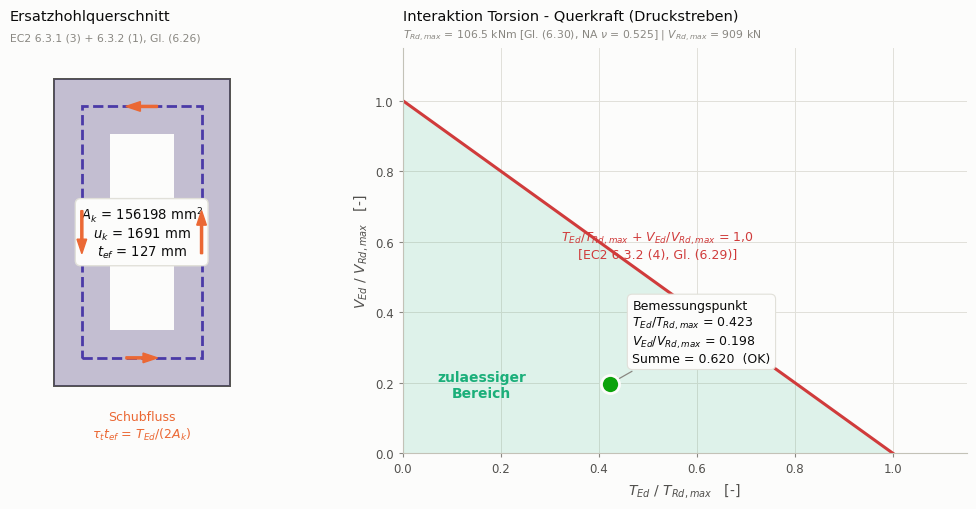

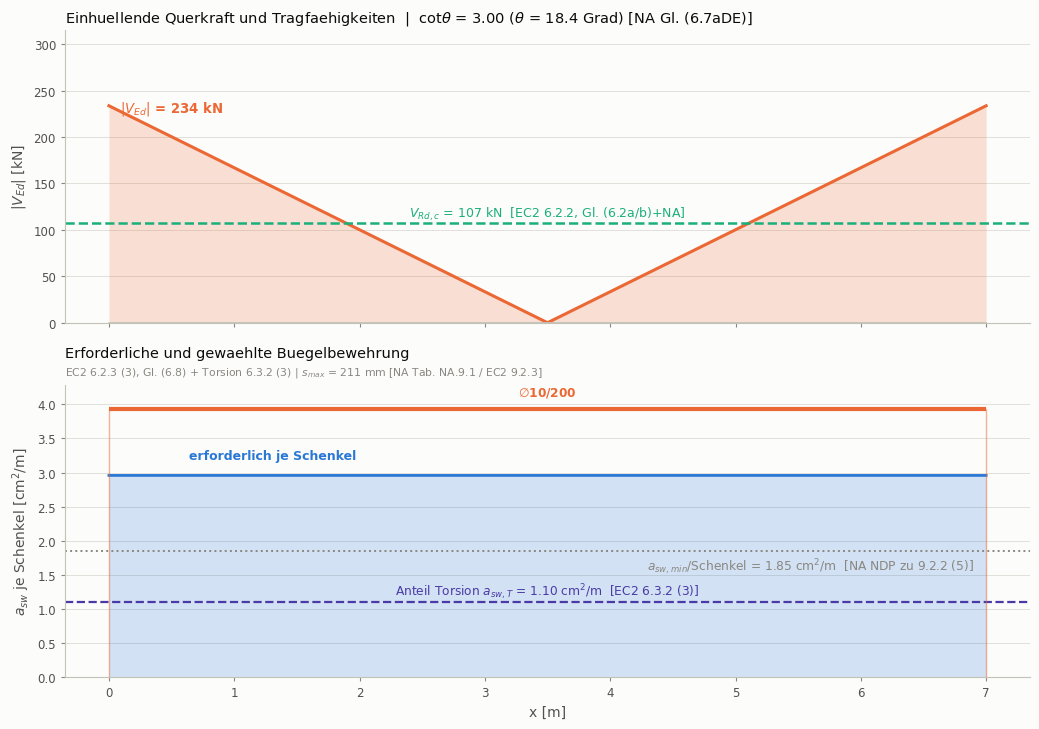

In [18]:
# --- GRAFIK: Ersatzhohlquerschnitt und Interaktion --------------------------
e_voll = EingabeBalken(L=L, auflager=[(0.0, GELENKIG, a_aufl), (L, GELENKIG, a_aufl)],
                       b=b_w, h=h, betonklasse=betonklasse, stahlsorte=stahlsorte,
                       expositionsklasse=expositionsklasse, d_g=d_g,
                       g_k=g_k, q_k=q_k, T_Ed=T_Ed, phi_laengs=phi_l,
                       phi_laengs_oben=16.0, phi_buegel=phi_w, n_schenkel=n_schenkel)
ber = bemessung_balken(e_voll)
G.bild_torsion(ber); plt.show()
G.bild_querkraft(ber); plt.show()

---
# Schritt 8 · Rissbreitenbegrenzung (GZG) — `[EC2 7.3]`

Quasi-ständige Kombination `[EC0 Gl. (6.16b)]`; zulässige Rissbreite $w_{max}$ nach
Expositionsklasse `[NA Tab. 7.1DE]` (XC1 → 0,4 mm; XC2…XS3 → 0,3 mm).

$$w_k=s_{r,max}\,(\varepsilon_{sm}-\varepsilon_{cm})\qquad\text{`[Gl. (7.8)]`}$$

$$\varepsilon_{sm}-\varepsilon_{cm}=
\frac{\sigma_s-k_t\dfrac{f_{ct,eff}}{\rho_{p,eff}}\left(1+\alpha_e\rho_{p,eff}\right)}{E_s}
\ \ge\ 0{,}6\,\frac{\sigma_s}{E_s}\ ,\qquad k_t=0{,}4\ \text{(Langzeit)}$$

$$\boxed{\ s_{r,max}=\frac{\varnothing}{3{,}6\,\rho_{p,eff}}\ \le\ \frac{\sigma_s\,\varnothing}{3{,}6\,f_{ct,eff}}\ }
\qquad\text{`[NA NDP zu 7.3.4 (3), Gl. (7.11DE)]`}$$

$$\rho_{p,eff}=\frac{A_s}{A_{c,eff}},\qquad A_{c,eff}=b\,h_{c,ef},\qquad
h_{c,ef}=\min\left\{2{,}5(h-d);\ \frac{h-x}{3};\ \frac{h}{2}\right\}$$

> 🇩🇪 Der Eurocode ohne NA verwendet $s_{r,max}=k_3 c+k_1k_2k_4\varnothing/\rho_{p,eff}$.
> Der deutsche NA ersetzt sie durch `(7.11DE)` — übernommen aus DIN 1045-1, `Gl. (137)`.

In [19]:
phi_kriech = 2.0
M_qs = q_qs*L**2/8.0
riss = rissbreite(qs, C, S, M_qs, As1_vorh, phi_l, 0.0, phi_kriech, bd["w_max"])

print(f"  M_qs = {M_qs:.2f} kNm   [EC0 Gl. (6.16b)]")
print(f"  E_c,eff = E_cm/(1+φ) = {C.Ec_eff(phi_kriech):.0f} N/mm²   α_e = {riss['alpha_e']:.2f}")
print(f"  x_II = {riss['x_II']:.1f} mm      I_II = {riss['I_II']:.4g} mm⁴")
print(f"  σ_s  = {riss['sigma_s']:.1f} N/mm²")
print(f"  h_c,ef = {riss['hc_ef']:.1f} mm   A_c,eff = {riss['Ac_eff']:.0f} mm²"
      f"   ρ_p,eff = {riss['rho_p_eff']:.5f}")
print(f"  ε_sm-ε_cm = {riss['eps_sm_cm']:.6f}"
      + ("  (Mindestwert 0,6σ_s/E_s maßgebend)" if riss["min_massgebend"] else ""))
print(f"  s_r,max = min({riss['sr_a']:.1f} ; {riss['sr_b']:.1f}) = {riss['sr_max']:.1f} mm  [Gl. (7.11DE)]")
print(f"\n  w_k = {riss['wk']:.4f} mm {'≤' if riss['ok'] else '>'} w_max = {riss['w_max']:.2f} mm"
      f"  →  {'ERFÜLLT' if riss['ok'] else 'NICHT ERFÜLLT'}  (η = {riss['ausnutzung']:.2f})")

  M_qs = 193.55 kNm   [EC0 Gl. (6.16b)]
  E_c,eff = E_cm/(1+φ) = 10946 N/mm²   α_e = 18.27
  x_II = 244.3 mm      I_II = 6.904e+09 mm⁴
  σ_s  = 213.0 N/mm²
  h_c,ef = 100.0 mm   A_c,eff = 40000 mm²   ρ_p,eff = 0.03927
  ε_sm-ε_cm = 0.000811
  s_r,max = min(141.5 ; 408.5) = 141.5 mm  [Gl. (7.11DE)]

  w_k = 0.1148 mm ≤ w_max = 0.40 mm  →  ERFÜLLT  (η = 0.29)


---
# Schritt 9 · Verformungsnachweis (GZG) — `[EC2 7.4]`

## 9.1 Biegeschlankheit — `[EC2 7.4.2 (2), Gl. (7.16a)/(7.16b)]`

$$\frac{l}{d}=K\left[11+1{,}5\sqrt{f_{ck}}\,\frac{\rho_0}{\rho}
+3{,}2\sqrt{f_{ck}}\left(\frac{\rho_0}{\rho}-1\right)^{3/2}\right]\quad(\rho\le\rho_0),
\qquad \rho_0=10^{-3}\sqrt{f_{ck}}$$

Vereinfachte Regel des NA `[NDP zu 7.4.2]`: $l/d\le 35$.

## 9.2 Verformungsberechnung — `[EC2 7.4.3 (3), Gl. (7.18)/(7.19)]`

$$\alpha=\zeta\,\alpha_{II}+(1-\zeta)\,\alpha_{I}\ ,\qquad
\zeta=1-\beta\left(\frac{M_{cr}}{M}\right)^2\ ,\qquad \beta=0{,}5$$

Die Durchbiegung folgt aus der Integration der Krümmung:
$$w(x)=\frac{x}{L}\int_0^L (L-t)\,\kappa(t)\,dt-\int_0^x (x-t)\,\kappa(t)\,dt$$

**Grenzwert** `[EC2 7.4.1 (4)]`: $w\le L/250$ unter quasi-ständiger Kombination.

In [20]:
kr = kruemmung(qs, C, S, M_qs, As1_vorh, 0.0, phi_kriech)
print(f"  M_cr = f_ctm·W = {kr['Mcr']:.2f} kNm   M_qs = {M_qs:.2f} kNm"
      f"  →  {'gerissen' if M_qs>kr['Mcr'] else 'ungerissen'}")
print(f"  ζ = 1 - 0,5(M_cr/M)² = {kr['zeta']:.4f}   [Gl. (7.19)]")
print(f"  Zustand I : x_I = {kr['x_I']:.1f} mm  I_I = {kr['I_I']:.4g} mm⁴")
print(f"  Zustand II: x_II= {kr['x_II']:.1f} mm  I_II= {kr['I_II']:.4g} mm⁴")
print(f"  1/r_m = {kr['kappa']:.3e} 1/mm   [Gl. (7.18)]")

db = nachweis_durchbiegung(qs_last.x, qs_last.M, qs, C, S, As1_vorh,
                           stabflaeche_n(2, 16.0), [(0.0, L)], phi_kriech, 0.0,
                           250.0, K=1.0, sigma_s=riss["sigma_s"])[0]
print(f"\n  w_max = {db['w_max']:.2f} mm bei x = {db['x_max']:.2f} m")
print(f"  Grenzwert L/250 = {db['w_grenz']:.2f} mm  →  η = {db['ausnutzung']:.3f}"
      f"  {'ERFÜLLT' if db['ok'] else 'NICHT ERFÜLLT'}")
print(f"  l/d vorh = {db['ld_vorh']:.1f} | zul. Gl. (7.16) = {db['ld_zul']:.1f}"
      f" | NA-Regel = {db['ld_NA']:.1f}")

  M_cr = f_ctm·W = 123.99 kNm   M_qs = 193.55 kNm  →  gerissen
  ζ = 1 - 0,5(M_cr/M)² = 0.7948   [Gl. (7.19)]
  Zustand I : x_I = 377.4 mm  I_I = 1.381e+10 mm⁴
  Zustand II: x_II= 244.3 mm  I_II= 6.904e+09 mm⁴
  1/r_m = 2.298e-06 1/mm   [Gl. (7.18)]

  w_max = 10.42 mm bei x = 3.50 m
  Grenzwert L/250 = 28.00 mm  →  η = 0.372  ERFÜLLT
  l/d vorh = 10.6 | zul. Gl. (7.16) = 31.2 | NA-Regel = 35.0


---
# Schritt 10 · Verankerung und Bewehrungsführung — `[EC2 8.4 / 9.2.1]`

## 10.1 Verbundspannung — `[EC2 8.4.2 (2), Gl. (8.2)]`
$$f_{bd}=2{,}25\,\eta_1\,\eta_2\,f_{ctd}$$

## 10.2 Verankerungslänge — `[EC2 8.4.3 (2) Gl. (8.3), 8.4.4 (1) Gl. (8.4)]`
$$l_{b,rqd}=\frac{\varnothing}{4}\cdot\frac{\sigma_{sd}}{f_{bd}}
\qquad l_{bd}=\alpha_1\alpha_2\alpha_3\alpha_4\alpha_5\,l_{b,rqd}\ \ge\ l_{b,min}$$

## 10.3 Versatzmaßregel — `[EC2 9.2.1.3 (2), Gl. (9.2)]`
$$a_l=\frac{z\,(\cot\theta-\cot\alpha)}{2}$$

Die Zugkraftlinie $F_s=M/z$ wird um $a_l$ verschoben. Bei Torsion ist die
**Torsionslängskraft zu addieren** `[EC2 6.3.2 (3)]`.

## 10.4 Endauflager — `[EC2 9.2.1.4 (2), Gl. (9.3)]`
$$F_{Ed}=|V_{Ed}|\,\frac{a_l}{z}+N_{Ed}$$

  f_bd = 2,25·1.0·1.00·1.149 = 2.59 N/mm²  [Gl. (8.2)]
  σ_sd = f_yd·A_erf/A_vorh = 427.2 N/mm²
  l_b,rqd = 826 mm      l_bd = 826 mm (l_b,min = 248 mm)

  a_l = 891 mm   F_Ed = |V_Ed|·a_l/z = 350.4 kN   [Gl. (9.3)]
  Torsionsanteil in der Zugzone ≈ 117.9 kN (Anteil b_k/u_k der Längsbewehrung)


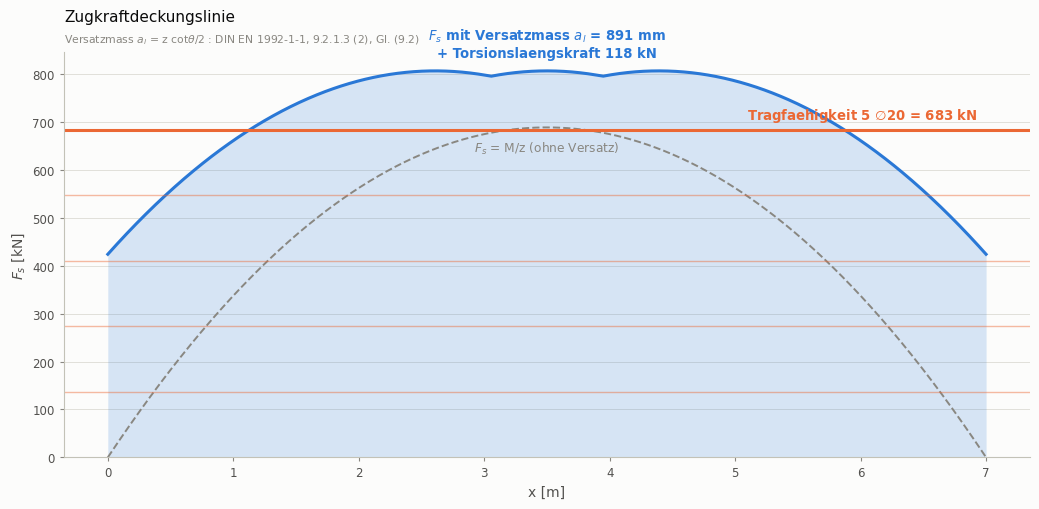

In [21]:
ver = verankerungslaenge(C, S, phi_l, guter_verbund=True,
                         As_erf=As1_erf, As_vorh=As1_vorh)
fb = verbundspannung(C, True, phi_l)
print(f"  f_bd = 2,25·{fb['eta1']:.1f}·{fb['eta2']:.2f}·{C.fctd:.3f} = {fb['fbd']:.2f} N/mm²  [Gl. (8.2)]")
print(f"  σ_sd = f_yd·A_erf/A_vorh = {ver['sigma_sd']:.1f} N/mm²")
print(f"  l_b,rqd = {ver['lb_rqd']:.0f} mm      l_bd = {ver['lbd']:.0f} mm "
      f"(l_b,min = {ver['lb_min']:.0f} mm)")
F_Ed_aufl = V_Ed_aufl*a_l/z_v
print(f"\n  a_l = {a_l:.0f} mm   F_Ed = |V_Ed|·a_l/z = {F_Ed_aufl:.1f} kN   [Gl. (9.3)]")
F_tor = asl_T*S.fyd/1000.0 * ehq["b_k"]/ehq["u_k"]
print(f"  Torsionsanteil in der Zugzone ≈ {F_tor:.1f} kN (Anteil b_k/u_k der Längsbewehrung)")
G.bild_zugkraftdeckung(ber); plt.show()

---
# Schritt 11 · Zusammenstellung und Bewehrungsplan

Alle Nachweise im Überblick; `bemessung_balken` führt sämtliche Schritte automatisch aus.

In [22]:
print(f"GESAMTERGEBNIS: {'NACHWEISE ERFÜLLT' if ber['ok_gesamt'] else 'NICHT ERFÜLLT'}\n")
print(f"{'Nachweis':<44s}{'E_d':>11s}  {'':2s} {'R_d':>11s}      η")
print("-"*90)
for c in ber["nachweise"]:
    eta = c["wert"]/c["grenzwert"] if c["vergleich"] == "<=" else c["grenzwert"]/c["wert"]
    print(f"{c['name']:<44s}{c['wert']:>11.2f}  {c['vergleich']:2s} {c['grenzwert']:>11.2f} "
          f"{c['einheit']:<5s} {eta:>6.3f}  {'OK' if c['ok'] else '← NICHT ERFÜLLT'}")
print("\nBEWEHRUNG")
print(f"  unten : {ber['n_unten']} ⌀{e_voll.phi_laengs:.0f} = {ber['As1_vorh']:.0f} mm²")
print(f"  oben  : {ber['n_oben']} ⌀{e_voll.phi_laengs_oben:.0f} = {ber['As_oben_vorh']:.0f} mm²")
t = ber["torsion"]
if t.erforderlich:
    print(f"  Torsion: zusätzlich {t.asl_gesamt:.0f} mm² Längsbewehrung auf "
          f"{t.n_laengsstaebe} Stäbe entlang u_k = {t.u_k:.0f} mm")
for zz in ber["querkraft"].bereiche:
    print(f"  Bügel : x = {zz['x1']:.2f}…{zz['x2']:.2f} m  ⌀{e_voll.phi_buegel:.0f}/{zz['s']:.0f} mm "
          f"({e_voll.n_schenkel} Schenkel, geschlossen)")

GESAMTERGEBNIS: NACHWEISE ERFÜLLT

Nachweis                                            E_d             R_d      η
------------------------------------------------------------------------------------------
Platz untere Bewehrung                           244.00  <=      400.00 mm     0.610  OK
Biegung Feld  M_Ed/M_Rd                          408.84  <=      415.50 kNm    0.984  OK
As,min Unterseite (Feldzug)                     1570.80  >=      397.63 mm2    0.253  OK
As,vorh <= As,max                               1972.92  <=    11200.00 mm2    0.176  OK
Druckstrebe V_Ed/V_Rd,max                        179.56  <=      908.82 kN     0.198  OK
Interaktion T/V (Druckstreben)                     0.62  <=        1.00 -      0.620  OK
Rissbreite wk                                      0.11  <=        0.40 mm     0.287  OK
Durchbiegung 0.0-7.0 m                            10.42  <=       28.00 mm     0.372  OK

BEWEHRUNG
  unten : 5 ⌀20 = 1571 mm²
  oben  : 2 ⌀16 = 402 mm²
  Torsion: zusätzli

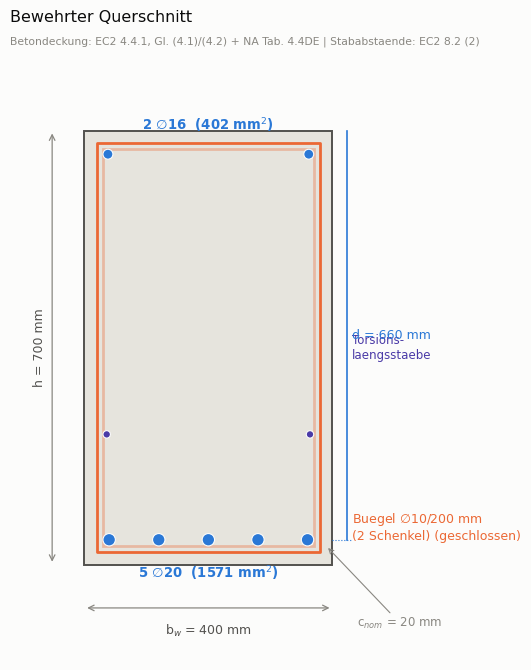

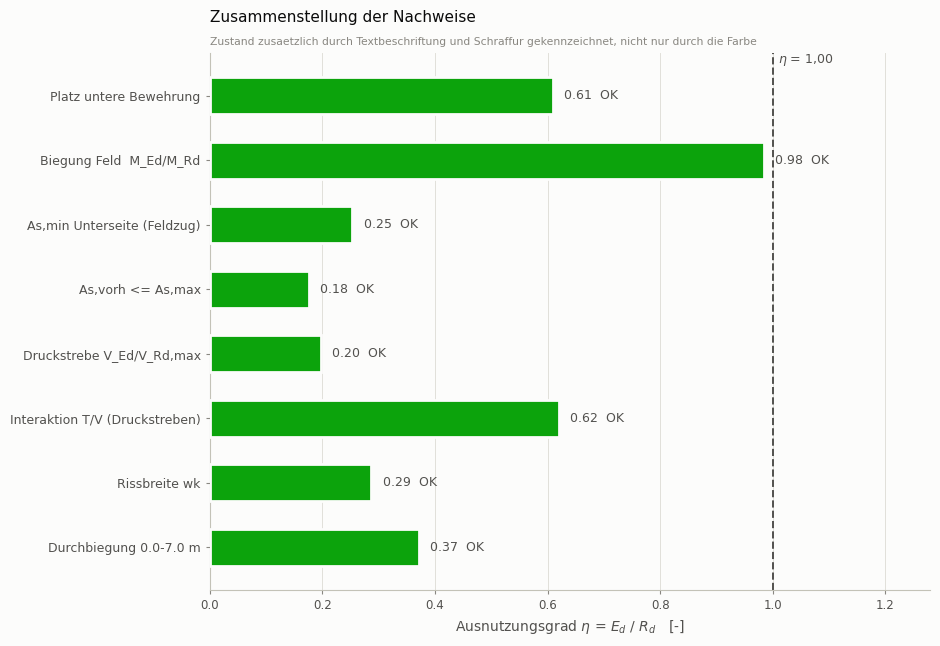

In [23]:
G.bild_querschnitt(ber); plt.show()
G.bild_ausnutzung(ber); plt.show()

---
# Anhang A · Bemessungstafel $\mu_{Eds}$ – $\omega$ – $\xi$ – $\zeta$

Berechnetes Gegenstück zu den *ω-Tafeln* bzw. *k$_d$-Tafeln* (Schneider Bautabellen),
gültig für $\le$ C50/60 mit B500 und $\varepsilon_{ud}=25‰$.

In [24]:
dgt = bemessungsdiagramm(C, S, n=3000, xi_max=0.62)
print(f"Bemessungstafel — Beton ≤ C50/60, Betonstahl {S.sorte}, ε_ud = 25 ‰")
print(f"{'μ_Eds':>8s} {'ω':>9s} {'ξ=x/d':>9s} {'ζ=z/d':>9s} {'ε_c [‰]':>9s} {'ε_s1 [‰]':>10s} {'σ_s':>8s}")
print("-"*68)
for m in [0.01,0.02,0.03,0.05,0.07,0.09,0.10,0.12,0.14,0.16,0.18,0.20,
          0.22,0.24,0.26,0.28,0.296,0.30,0.32,0.34,0.36]:
    if m > dgt["mu"][-1]:
        break
    vals = [float(np.interp(m, dgt["mu"], dgt[k]))
            for k in ("omega", "xi", "zeta", "eps_c", "eps_s", "sigma_s")]
    marke = "  ← μ_lim (x_u/d = 0,45)" if abs(m-0.296) < 1e-9 else ""
    print(f"{m:8.3f} {vals[0]:9.4f} {vals[1]:9.4f} {vals[2]:9.4f} {vals[3]:9.2f} "
          f"{vals[4]:10.2f} {vals[5]:8.1f}{marke}")

Bemessungstafel — Beton ≤ C50/60, Betonstahl B500B, ε_ud = 25 ‰
   μ_Eds         ω     ξ=x/d     ζ=z/d   ε_c [‰]   ε_s1 [‰]      σ_s
--------------------------------------------------------------------
   0.010    0.0101    0.0300    0.9896      0.77      25.00    434.8
   0.020    0.0203    0.0438    0.9845      1.15      25.00    434.8
   0.030    0.0306    0.0553    0.9801      1.46      25.00    434.8
   0.050    0.0515    0.0761    0.9713      2.06      25.00    434.8
   0.070    0.0728    0.0969    0.9616      2.68      25.00    434.8
   0.090    0.0946    0.1181    0.9512      3.35      25.00    434.8
   0.100    0.1057    0.1306    0.9457      3.50      23.29    434.8
   0.120    0.1285    0.1587    0.9340      3.50      18.55    434.8
   0.140    0.1518    0.1876    0.9220      3.50      15.16    434.8
   0.160    0.1759    0.2173    0.9096      3.50      12.61    434.8
   0.180    0.2007    0.2479    0.8969      3.50      10.62    434.8
   0.200    0.2263    0.2796    0.8837 

---
# Anhang B · Wesentliche Abweichungen des deutschen NA vom Eurocode

| Größe | EC2 (empfohlen) | **DIN EN 1992-1-1/NA** | Abschnitt |
|---|---|---|---|
| $\alpha_{cc}$ | 1,00 | **0,85** | NDP zu 3.1.6 (1)P |
| $\varepsilon_{ud}$ | $0{,}9\,\varepsilon_{uk}$ | **25 ‰** | NDP zu 3.2.7 (2) |
| $k_1$, $k_2$ (Umlagerung) | 0,44 / 1,25 | **0,64 / 0,80** → $x_u/d\le0{,}45$ | NDP zu 5.5 (4) |
| $C_{Rd,c}$ | $0{,}18/\gamma_C=0{,}12$ | **$0{,}15/\gamma_C=0{,}10$** | NDP zu 6.2.2 (1) |
| $v_{min}$ | $0{,}035\,k^{3/2}f_{ck}^{1/2}$ | **Gl. (6.3aDE)** | NDP zu 6.2.2 (1) |
| $\cot\theta$ | 1,0…2,5 (frei) | **Formel Gl. (6.7aDE)**, 1,0…3,0 | NDP zu 6.2.3 (2) |
| $\nu_1$ (Querkraft) | $0{,}6(1-f_{ck}/250)$ | **$0{,}75\,\nu_2$** | NDP zu 6.2.3 (3) |
| **$\nu$ (Torsion)** | $0{,}6(1-f_{ck}/250)$ | **$0{,}525\,\nu_2$ (voll) / $0{,}75\,\nu_2$ (Kasten)** | NDP zu 6.3.2 (4) |
| **Verzicht Torsionsbew.** | Gl. (6.31) | **Gl. (6.31aDE)/(6.31bDE)** | NDP zu 6.3.2 (5) |
| $z$ (Querkraft) | $0{,}9d$ | **$\min\{0{,}9d;\,d-2c_{v,l};\,d-c_{v,l}-30\}$** | NDP zu 6.2.3 (1) |
| $s_{r,max}$ | $k_3c+k_1k_2k_4\varnothing/\rho_{p,eff}$ | **Gl. (7.11DE)** | NDP zu 7.3.4 (3) |
| $\rho_{w,min}$ | $0{,}08\sqrt{f_{ck}}/f_{yk}$ | **$0{,}16\,f_{ctm}/f_{yk}$** | NDP zu 9.2.2 (5) |
| $\Delta c_{dev}$ | 10 mm | **15 mm** (10 mm bei XC1) | NDP zu 4.4.1.3 (1)P |

---
# Anhang C · Verzeichnis aller verwendeten Normstellen

In [25]:
print(normentabelle())

VERWENDETE NORMSTELLEN

--- DIN 488-1:2009-08 ---
  Tab. 4 / 5                                             Betonstahl B500A / B500B: fyk = 500 N/mm2

--- DIN EN 1990/NA:2010-12 ---
  Tab. NA.A.1.1                                          Kombinationsbeiwerte psi_0 / psi_1 / psi_2
  Tab. NA.A.1.2(B)                                       Teilsicherheitsbeiwerte der Einwirkungen gamma_G = 1,35 / gamma_Q = 1,50

--- DIN EN 1990:2010-12 ---
  6.4.3.2, Gl. (6.10)                                    Grundkombination GZT: sum(gamma_G G) + gamma_Q Q_1 + sum(gamma_Q psi_0 Q_i)
  6.5.3, Gl. (6.16b)                                     Quasi-staendige Kombination GZG: sum(G) + sum(psi_2 Q)

--- DIN EN 1991-1-1:2010-12 ---
  Tab. A.1                                               Wichte von Stahlbeton gamma = 25,0 kN/m3

--- DIN EN 1992-1-1/NA:2013-04 ---
  2.4.2.4 (1), Tab. 2.1DE                                Teilsicherheitsbeiwerte der Baustoffe gamma_C = 1,50 / gamma_S = 1,15
  NDP zu 3.1.6 (1)P  

---
# Anhang D · Vollständiger Bemessungsbericht

In [26]:
print(bericht_text(ber, mit_normen=False))

BEMESSUNG EINES STAHLBETONBALKENS
Norm: DIN EN 1992-1-1:2011-01 + DIN EN 1992-1-1/NA:2013-04 (Eurocode 2 mit deutschem NA)
Traeger 7.00 m | Querschnitt Rechteckquerschnitt b/h = 400/700 mm | C30/37 | B500B


----------------------------------------------------------------------------------------------------
1. BAUSTOFFE
   Normgrundlage:
      - DIN EN 1992-1-1:2011-01, Abschnitt 3.1.2, Tab. 3.1 - Festigkeitsklassen und Eigenschaften des Betons (fck, fcm, fctm, Ecm)  (~ DIN 1045-1, 9.1.2, Tab. 9)
      - DIN EN 1992-1-1:2011-01, Abschnitt 3.1.6 (1)P Gl. (3.15) - Bemessungswert der Betondruckfestigkeit fcd = alpha_cc fck / gamma_C  (~ DIN 1045-1, 9.1.6)
      - DIN EN 1992-1-1/NA:2013-04, Abschnitt NDP zu 3.1.6 (1)P - alpha_cc = 0,85 (Normalbeton)
      - DIN EN 1992-1-1:2011-01, Abschnitt 3.1.6 (2)P Gl. (3.16) - Bemessungswert der Betonzugfestigkeit fctd = alpha_ct fctk;0,05 / gamma_C
      - DIN EN 1992-1-1/NA:2013-04, Abschnitt NDP zu 3.1.6 (2)P - alpha_ct = 0,85
      - DIN EN 1992-

---

### ⚠️ Umfang und Grenzen

Erfasst: **Biegung mit Längskraft (EC2 6.1)**, **Querkraft (6.2)**, **Torsion (6.3)**
einschließlich Interaktion, **Mindest-/Höchstbewehrung (9.2.1.1)**, **Rissbreite (7.3)**,
**Verformung (7.4)**, **Betondeckung (4.4)** und **Verankerung (8.4 / 9.2.1)**.

**Nicht** erfasst: Durchstanzen (6.4), Kippen schlanker Träger (5.9), Ermüdung (6.8),
Vorspannung (5.10), außergewöhnliche und seismische Bemessungssituationen,
Brandfall (EN 1992-1-2), Leichtbeton (Kap. 11).

Alle Ergebnisse sind von einem verantwortlichen Ingenieur gegen die gültige Ausgabe von
DIN EN 1992-1-1 und ihres Nationalen Anhangs zu prüfen.